Exploratory Data Analysis of Large-Scale Retail Transaction (EDA)

In [181]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from matplotlib.colors import ListedColormap
from scipy.stats import kurtosis
from scipy.stats import zscore

Load Dataset

In [182]:
df = pd.read_csv("C:\\Users\\sarth\\OneDrive\\Documents\\Digicrome\\Intership 12 Month\\Project 3 Python\\retail_large_dataset.csv")

In [183]:
df.shape

(100000, 18)

In [184]:
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [186]:
df.describe(include='all')

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
count,100000,100000.000000,100000,100000,100000,100000,100000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000.000000,100000
unique,100000,NaN,2,10,9,3,100000,1095,6,21,NaN,NaN,NaN,NaN,4,2,NaN,2
top,C109983,NaN,Male,Hyderabad,Maharashtra,New,O149983,2023-04-12,Health,Protein Powder,NaN,NaN,NaN,NaN,Credit Card,Express,NaN,No
freq,1,NaN,50111,10150,19952,33488,1,124,16858,5668,NaN,NaN,NaN,NaN,25307,50008,NaN,85189
mean,NaN,41.561830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30164.526720,2.501790,15.009890,64165.723382,NaN,NaN,5.505540,NaN
std,NaN,13.852439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17139.679807,1.120058,8.953296,49969.280150,NaN,NaN,2.872868,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.000000,1.000000,0.000000,357.000000,NaN,NaN,1.000000,NaN
25%,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15375.000000,1.000000,7.000000,24705.000000,NaN,NaN,3.000000,NaN
50%,NaN,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30148.000000,3.000000,15.000000,49752.390000,NaN,NaN,5.000000,NaN
75%,NaN,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44957.000000,4.000000,23.000000,94046.070000,NaN,NaN,8.000000,NaN


Missing Values

In [187]:
df.isnull().sum()

customer_id            0
age                    0
gender                 0
city                   0
state                  0
customer_segment       0
order_id               0
order_date             0
product_category       0
product_subcategory    0
product_price          0
quantity               0
discount_percentage    0
final_price            0
payment_method         0
shipping_type          0
delivery_days          0
return_status          0
dtype: int64

Duplicate Records

In [188]:
df.duplicated().sum()

np.int64(0)

In [189]:
df.drop_duplicates(inplace=True)

Numerical Columns

In [190]:
num_cols=df.select_dtypes(include=np.number).columns

num_cols

Index(['age', 'product_price', 'quantity', 'discount_percentage',
       'final_price', 'delivery_days'],
      dtype='object')

Categorical Columns

In [191]:
cat_cols=df.select_dtypes(include='object').columns

cat_cols

Index(['customer_id', 'gender', 'city', 'state', 'customer_segment',
       'order_id', 'order_date', 'product_category', 'product_subcategory',
       'payment_method', 'shipping_type', 'return_status'],
      dtype='object')

 Display the frequency distribution of all categorical features
 This helps understand category balance and identify dominant classes.
 Used for exploratory data analysis (EDA) before feature engineering.

In [192]:
for col in cat_cols: display(df[col].value_counts())

customer_id
C109983    1
C109982    1
C109981    1
C109980    1
C109979    1
          ..
C10004     1
C10003     1
C10002     1
C10001     1
C10000     1
Name: count, Length: 100000, dtype: int64

gender
Male      50111
Female    49889
Name: count, dtype: int64

city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64

state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64

customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64

...

product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64

product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses            5477
Perfume           5423
Jeans             4278
Headphones        4265
Blender           4255
Cookware          4219
Vacuum Cleaner    4199
Smartphone        4198
Microwave         4175
Shoes             4145
Men T-Shirt       4132
Tablet            4070
Women Dress       4058
Laptop            4043
Name: count, dtype: int64

payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64

shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64

return_status
No     85189
Yes    14811
Name: count, dtype: int64

Univariate Analysis
Histogram

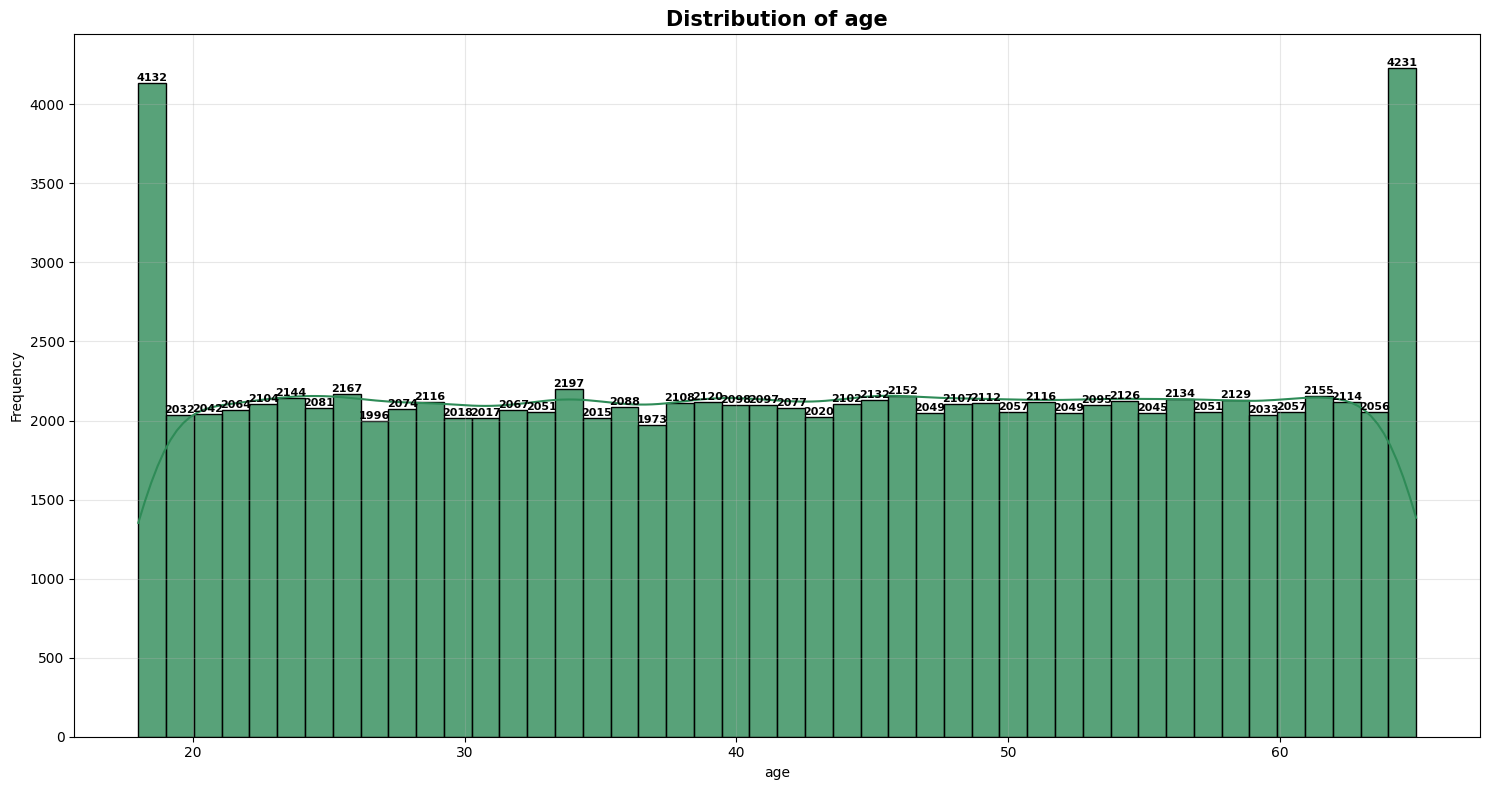

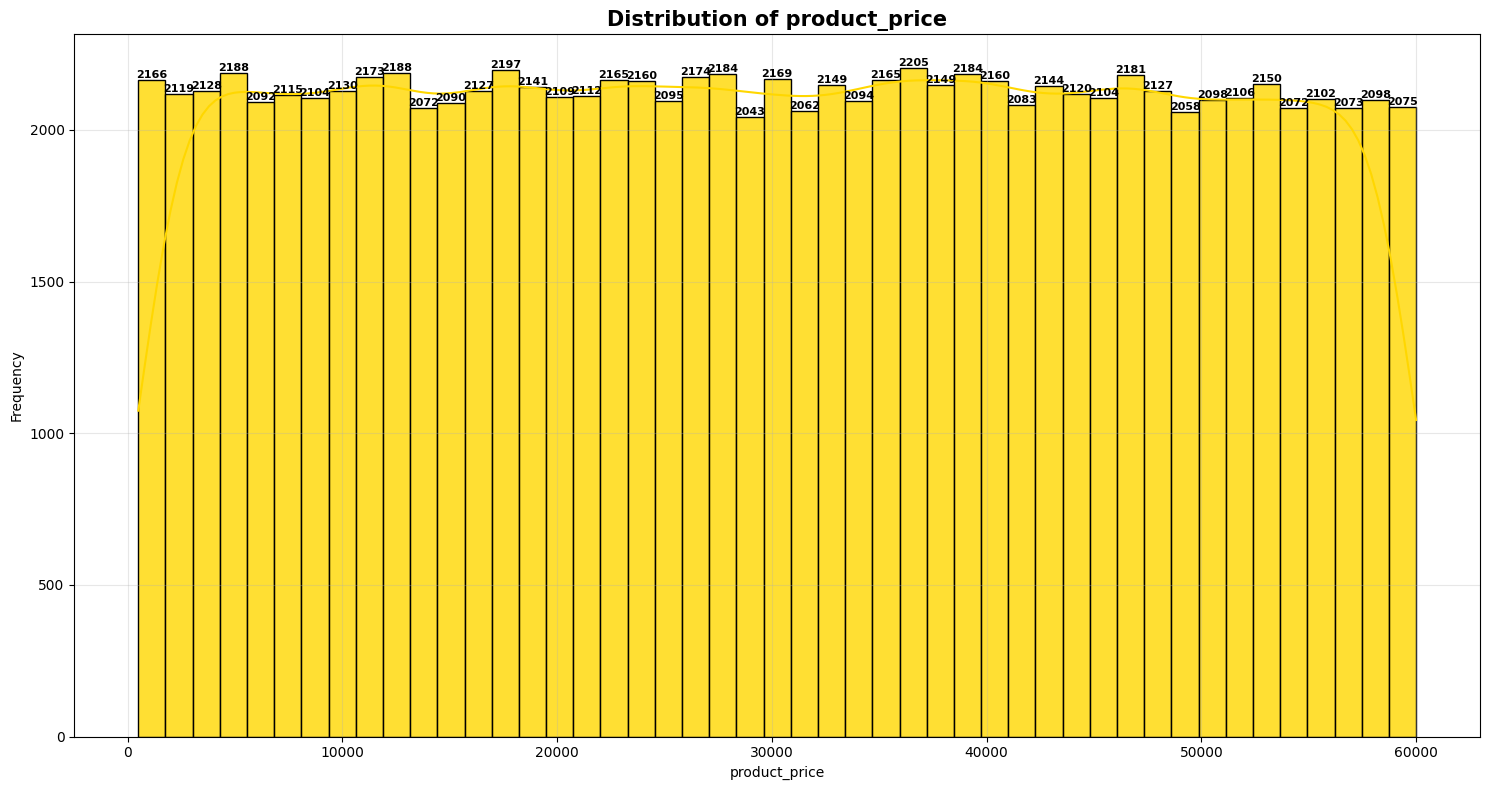

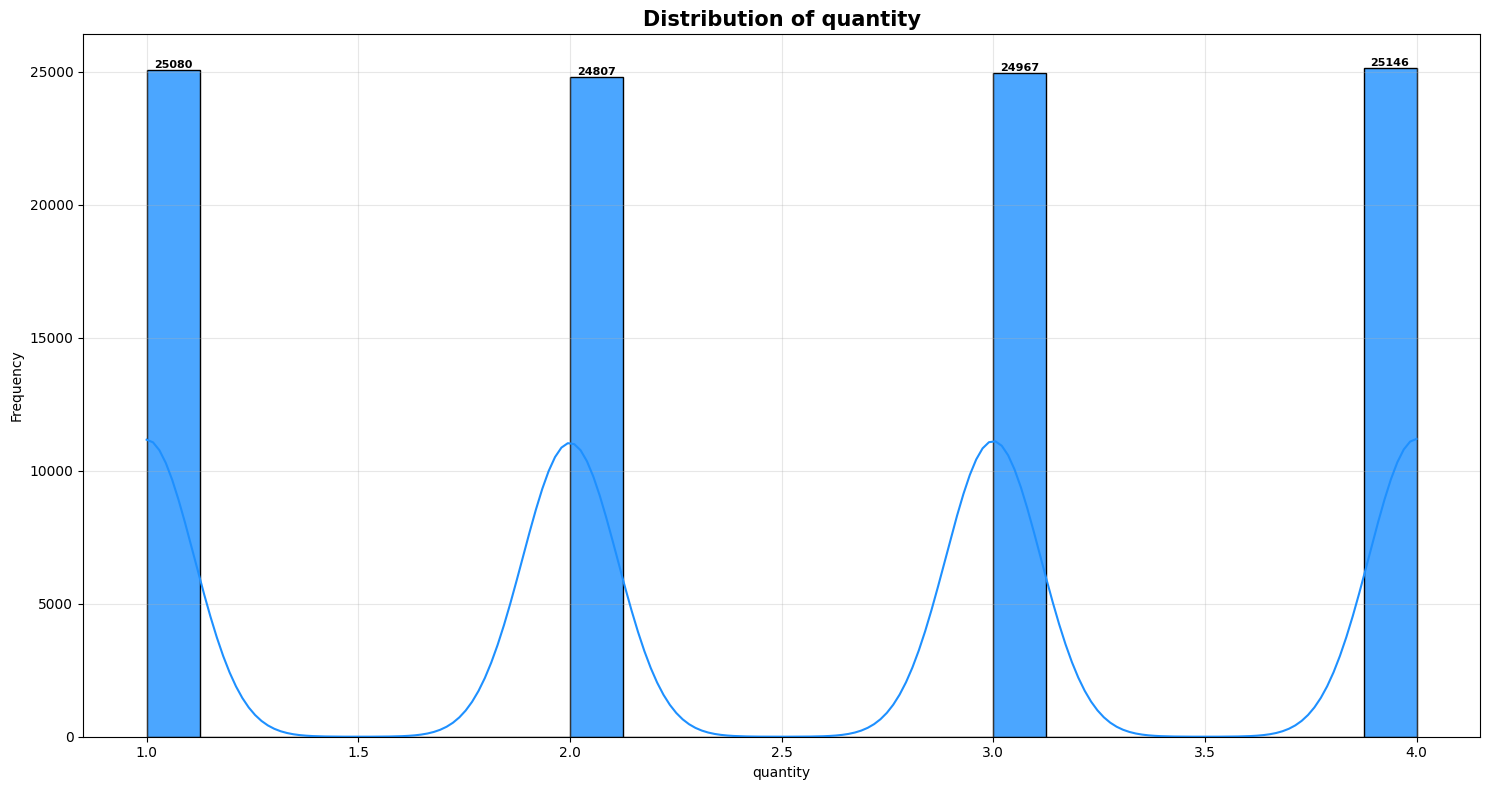

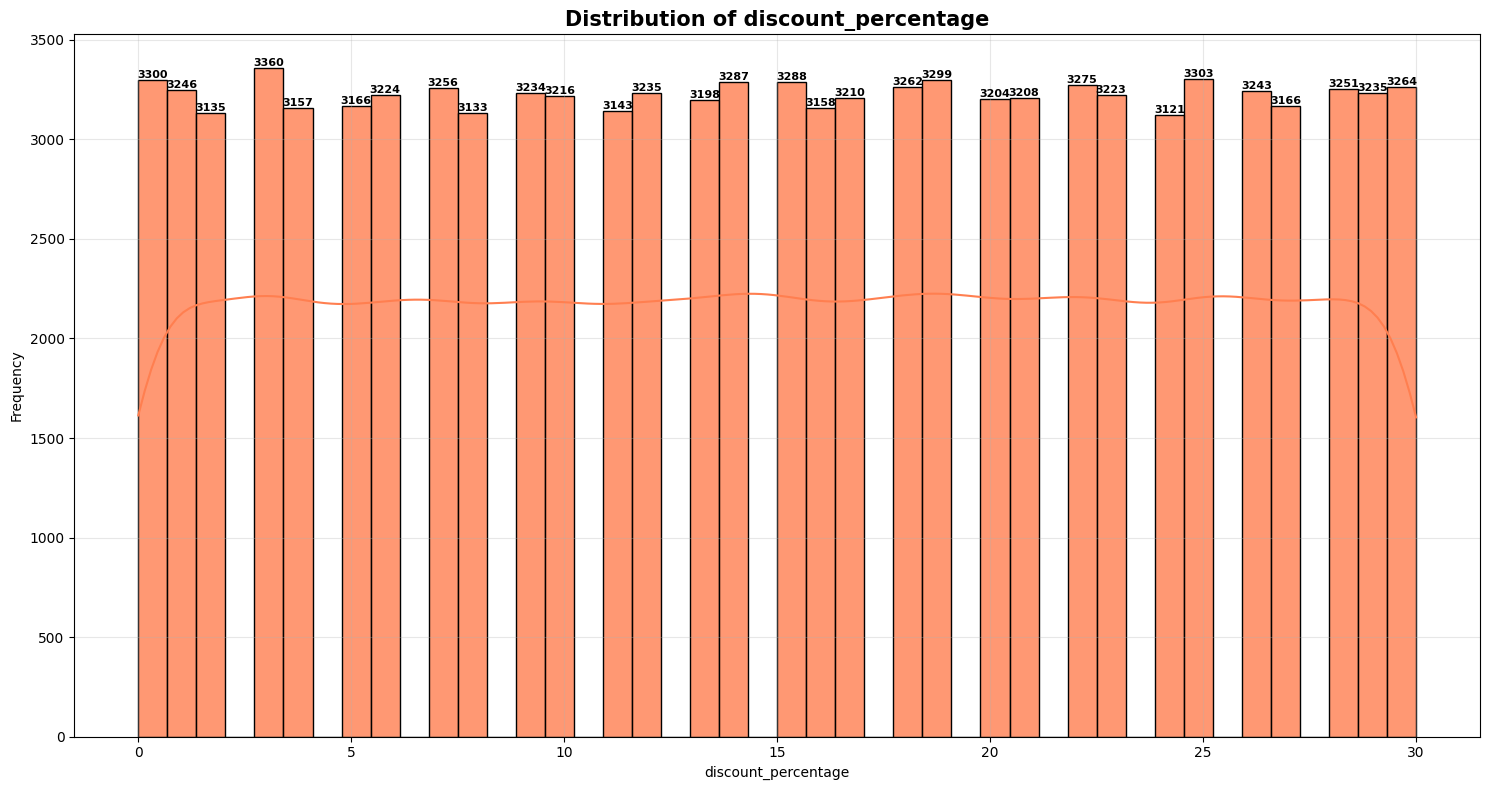

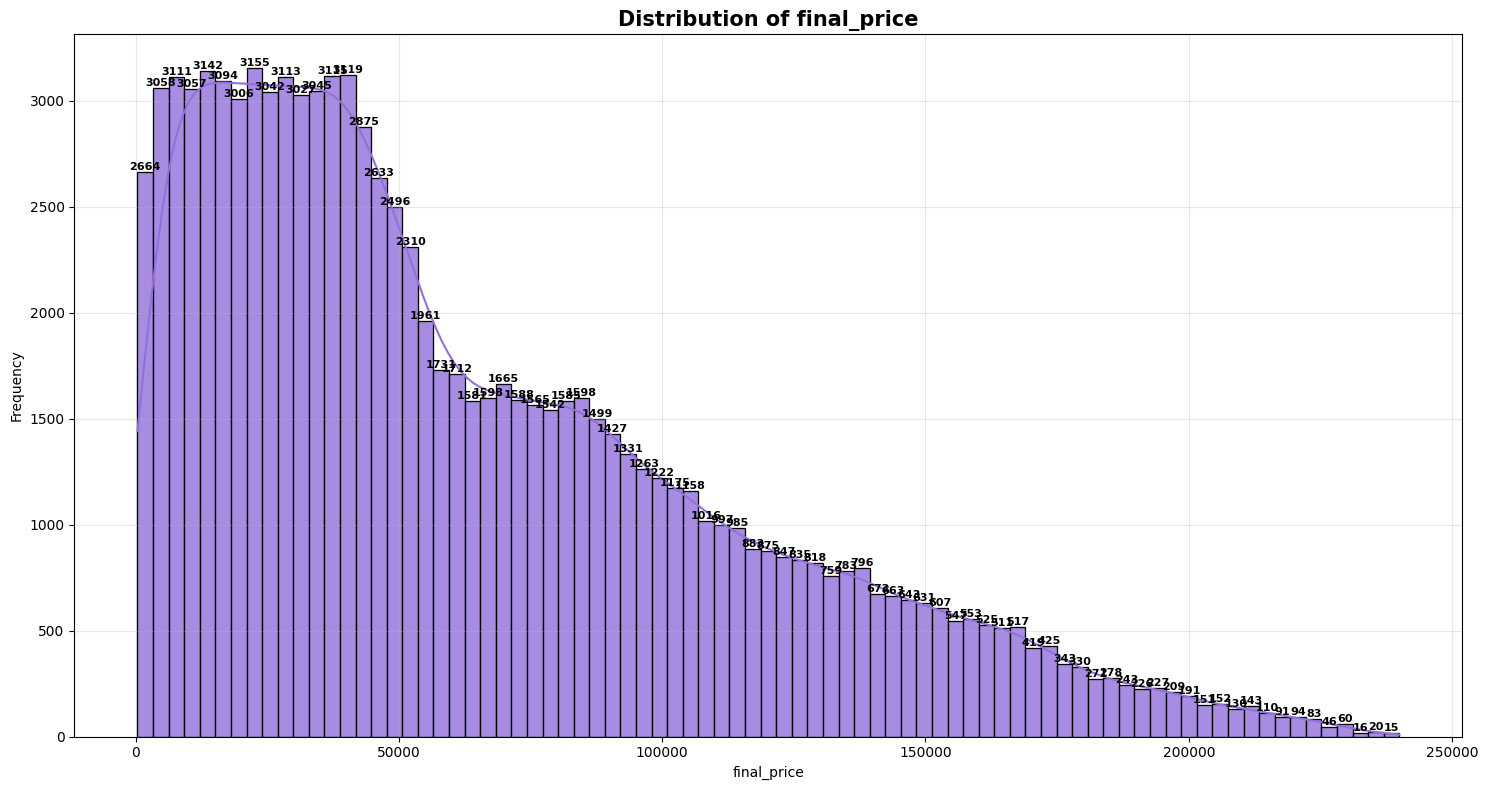

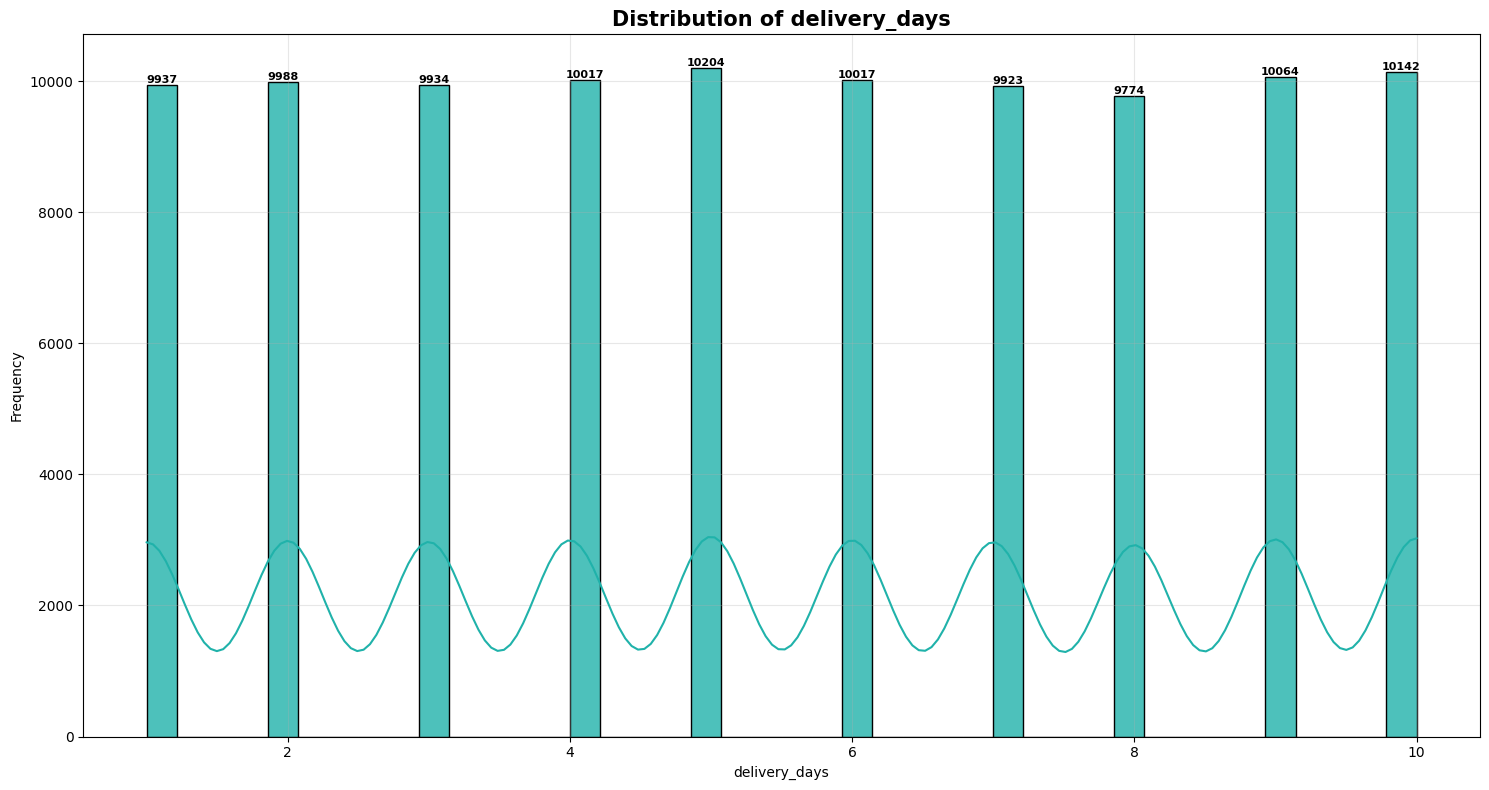

In [193]:
colors = ['#2E8B57','#FFD700','#1E90FF','#FF7F50','#9370DB','#20B2AA']

for i, col in enumerate(num_cols):
    plt.figure(figsize=(15,8))
    ax = sns.histplot(data=df, x=col,  kde=True,  color=colors[i % len(colors)], edgecolor='black',  alpha=0.8)

    # Add count labels on histogram bars
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center',  va='bottom', fontsize=8,  fontweight='bold' )
    plt.title(f'Distribution of {col}', fontsize=15, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

Count Plot for Categorical Features


Gender Distribution
gender
Male      50111
Female    49889
Name: count, dtype: int64

Percentage:
gender
Male      50.11 %
Female    49.89 %
Name: proportion, dtype: object


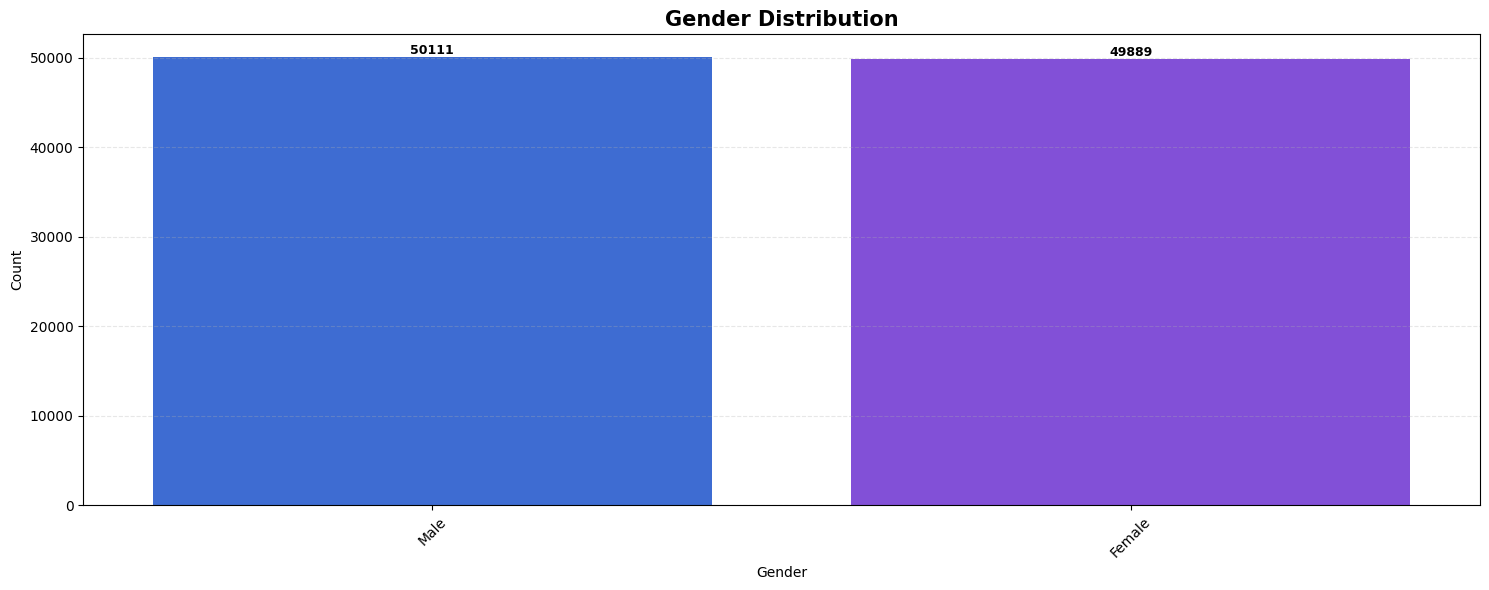


Customer Segment Distribution
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64

Percentage:
customer_segment
New        33.49 %
Regular    33.36 %
Premium    33.15 %
Name: proportion, dtype: object


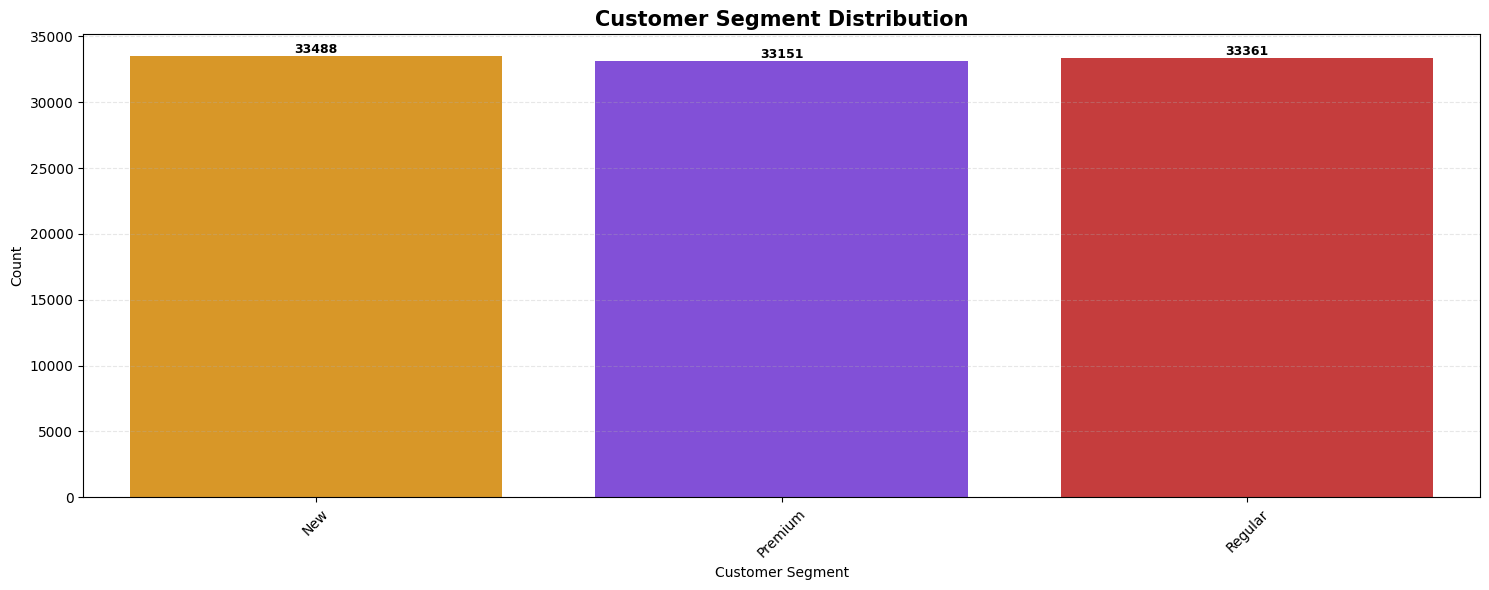


Product Category Distribution
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64

Percentage:
product_category
Health            16.86 %
Home & Kitchen    16.85 %
Fashion           16.61 %
Grocery           16.59 %
Electronics       16.58 %
Beauty            16.51 %
Name: proportion, dtype: object


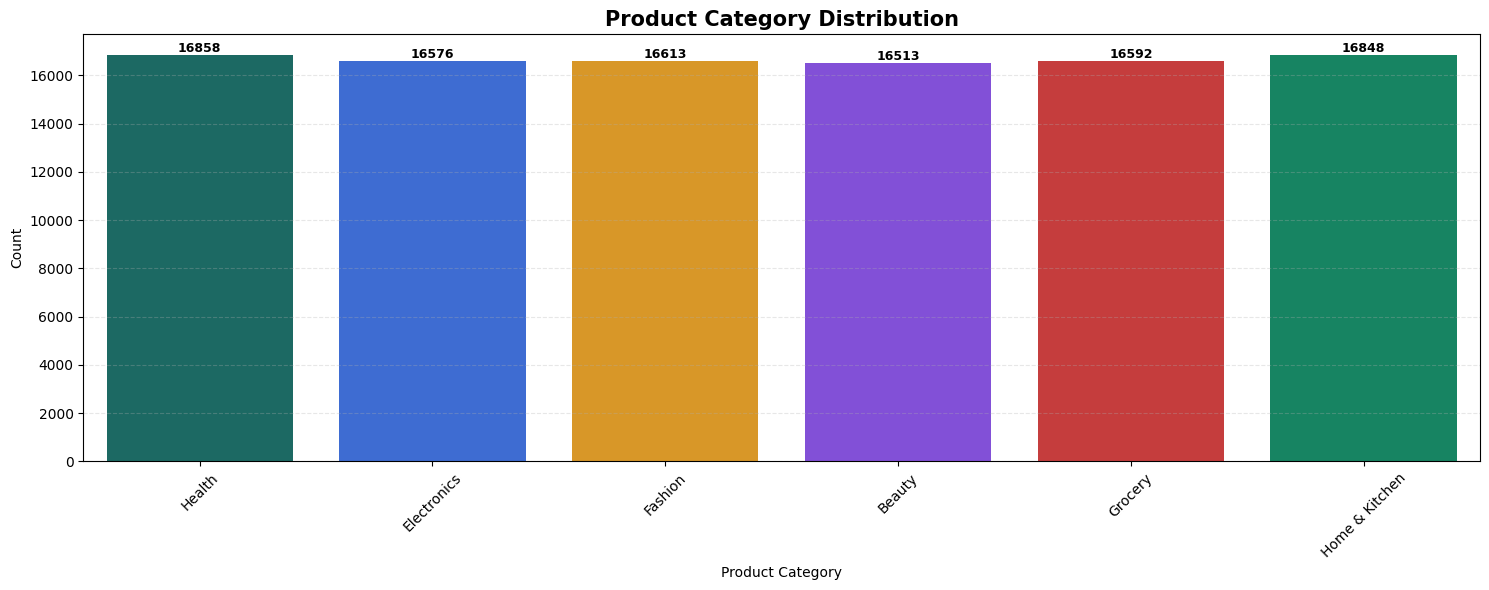


Payment Method Distribution
payment_method
Credit Card         25307
UPI                 25139
Cash on Delivery    24994
Debit Card          24560
Name: count, dtype: int64

Percentage:
payment_method
Credit Card         25.31 %
UPI                 25.14 %
Cash on Delivery    24.99 %
Debit Card          24.56 %
Name: proportion, dtype: object


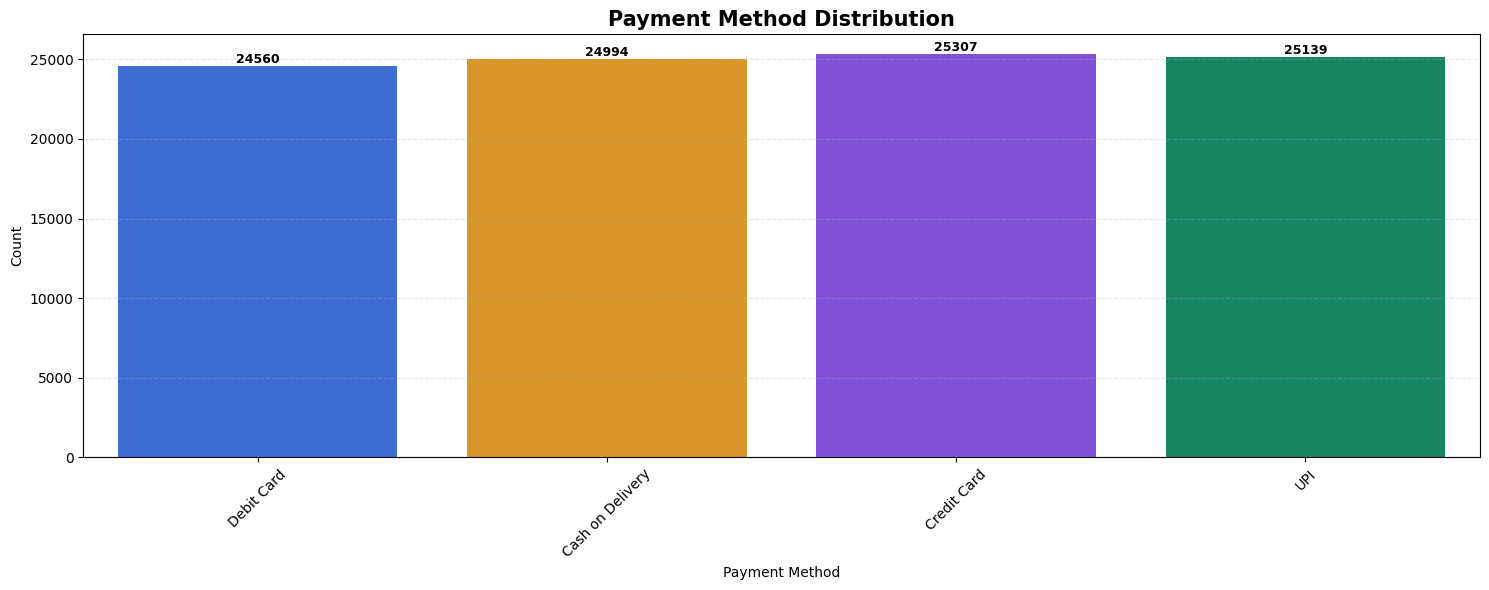


Shipping Type Distribution
shipping_type
Express     50008
Standard    49992
Name: count, dtype: int64

Percentage:
shipping_type
Express     50.01 %
Standard    49.99 %
Name: proportion, dtype: object


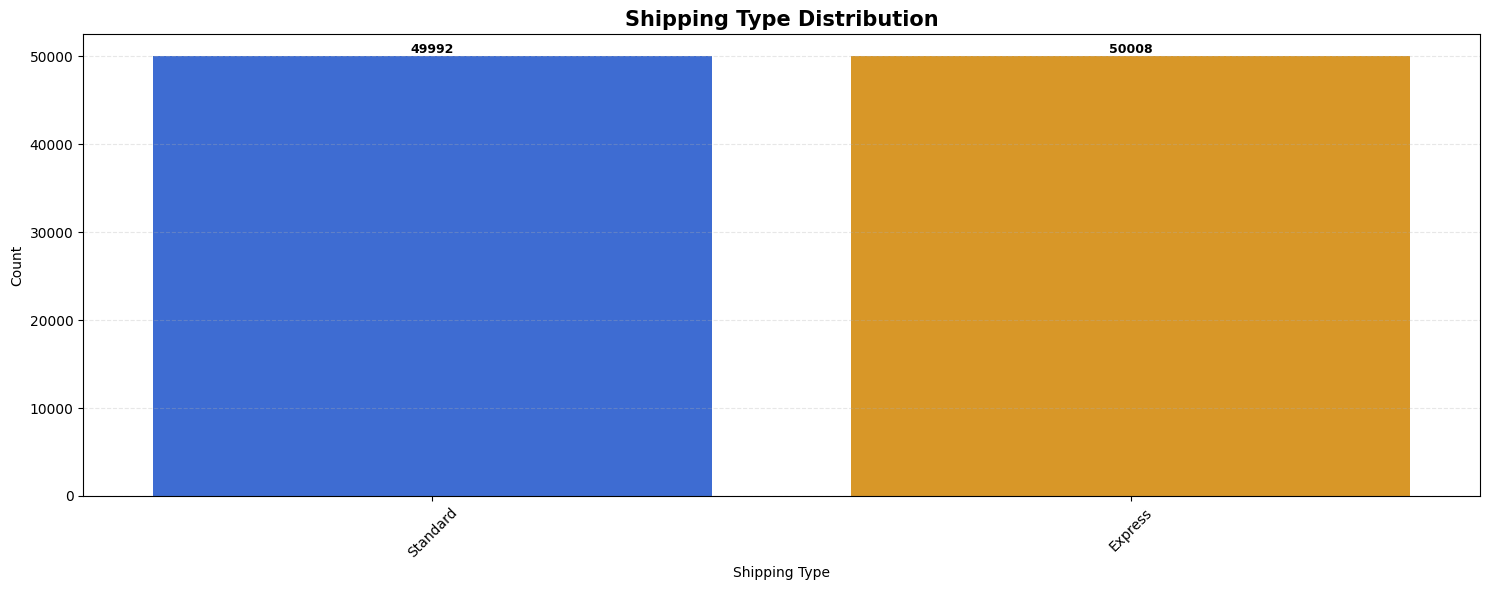


Return Status Distribution
return_status
No     85189
Yes    14811
Name: count, dtype: int64

Percentage:
return_status
No     85.19 %
Yes    14.81 %
Name: proportion, dtype: object


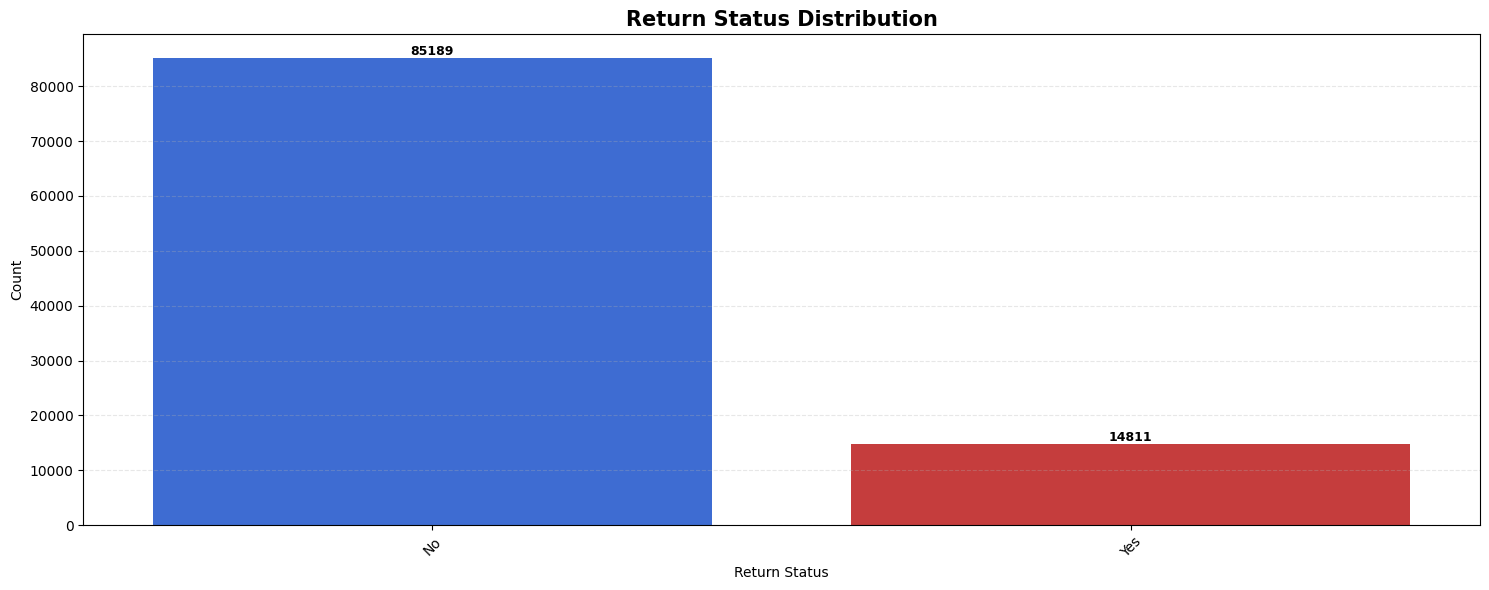


City Distribution
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64

Percentage:
city
Hyderabad    10.15 %
Ahmedabad    10.06 %
Bangalore    10.05 %
Mumbai       10.02 %
Chennai       9.99 %
Noida         9.96 %
Delhi         9.96 %
Kolkata       9.96 %
Pune          9.94 %
Jaipur        9.92 %
Name: proportion, dtype: object


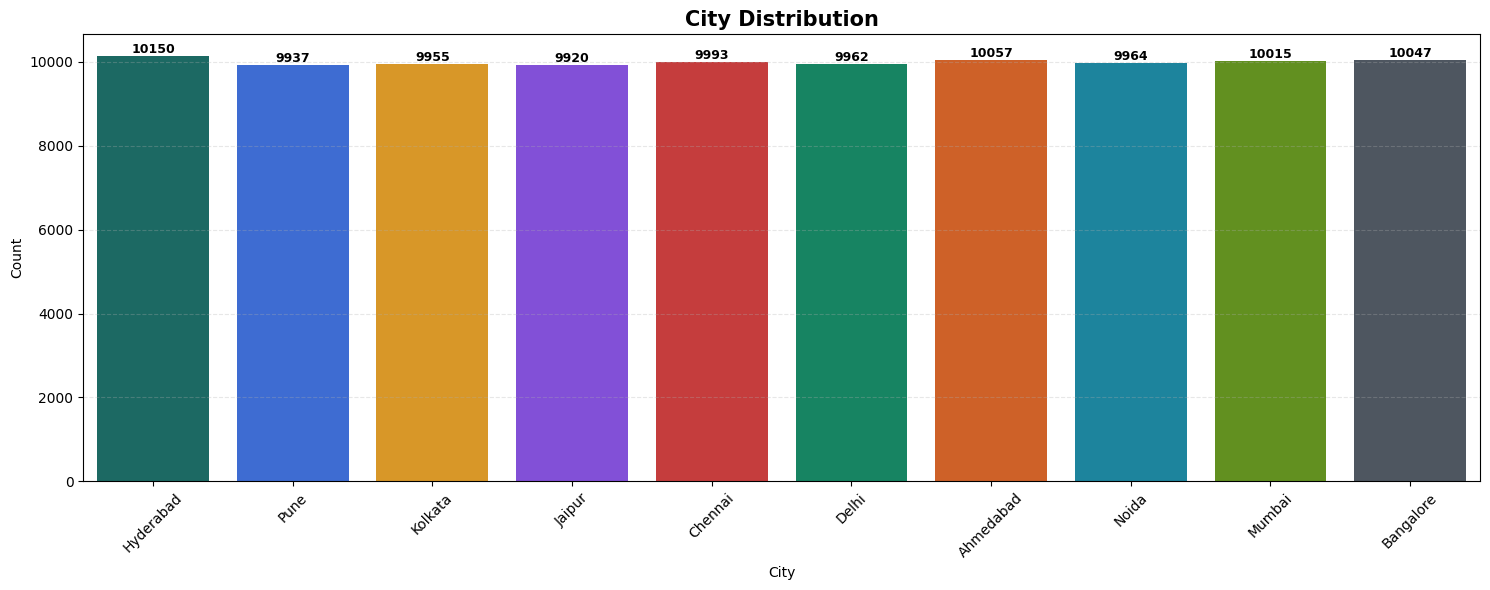


Month Distribution
Month
January      8764
August       8600
December     8585
April        8405
May          8399
July         8328
March        8322
October      8289
September    8280
November     8238
June         8066
February     7724
Name: count, dtype: int64

Percentage:
Month
January      8.76 %
August        8.6 %
December     8.58 %
April         8.4 %
May           8.4 %
July         8.33 %
March        8.32 %
October      8.29 %
September    8.28 %
November     8.24 %
June         8.07 %
February     7.72 %
Name: proportion, dtype: object


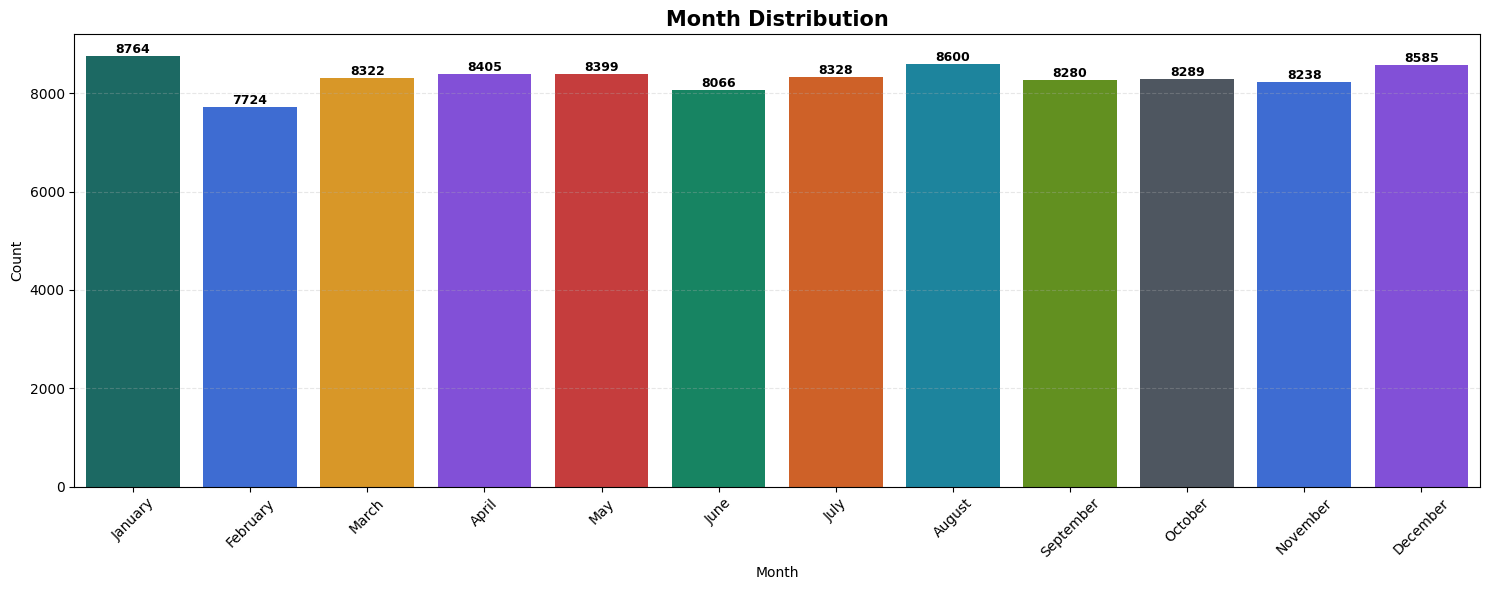


State Distribution
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64

Percentage:
state
Maharashtra      19.95 %
Telangana        10.15 %
Gujarat          10.06 %
Karnataka        10.05 %
Tamil Nadu        9.99 %
Uttar Pradesh     9.96 %
Delhi             9.96 %
West Bengal       9.96 %
Rajasthan         9.92 %
Name: proportion, dtype: object


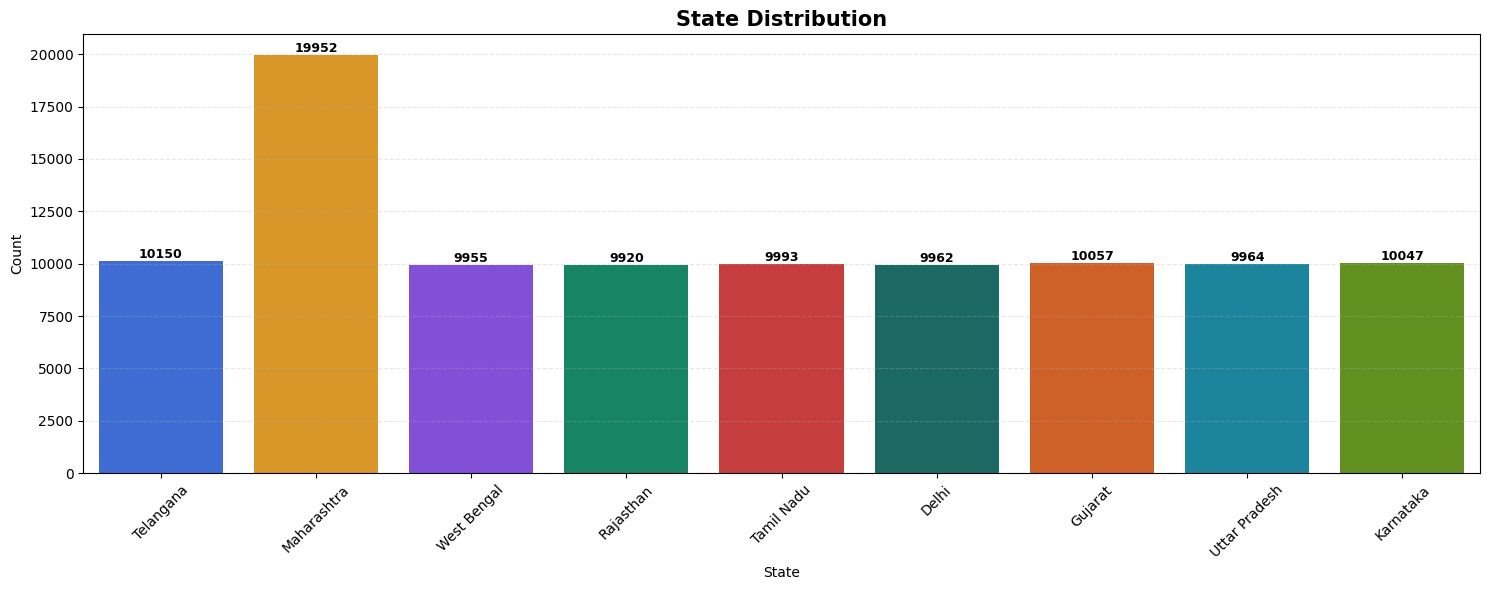

In [194]:
# 1. Create Month column
df['Month'] = pd.Categorical(
    pd.to_datetime(df['order_date']).dt.month_name(),
    categories=[
        'January','February','March','April','May','June',
        'July','August','September','October','November','December'
    ],
    ordered=True
)

# 2. Define cat_cols
cat_cols = {
    'gender': ['#2563EB', '#7C3AED'],
    'customer_segment': ['#F59E0B', '#7C3AED', '#DC2626'],
    'product_category': ['#0F766E', '#2563EB', '#F59E0B', '#7C3AED', '#DC2626', '#059669'],
    'payment_method': ['#2563EB', '#F59E0B', '#7C3AED', '#059669'],
    'shipping_type': ['#2563EB', '#F59E0B'],
    'return_status': ['#2563EB', '#DC2626'],
    'city': ['#0F766E', '#2563EB', '#F59E0B', '#7C3AED', '#DC2626',
             '#059669', '#EA580C', '#0891B2', '#65A30D', '#4B5563'],
    'Month': ['#0F766E', '#2563EB', '#F59E0B', '#7C3AED', '#DC2626',
              '#059669', '#EA580C', '#0891B2', '#65A30D', '#4B5563',
              '#2563EB', '#7C3AED'],
    'state': ['#2563EB', '#F59E0B', '#7C3AED', '#059669', '#DC2626',
              '#0F766E', '#EA580C', '#0891B2', '#65A30D', '#4B5563']
}

for col, colors in cat_cols.items():

    print(f"\n{col.replace('_', ' ').title()} Distribution")
    print(df[col].value_counts())

    print("\nPercentage:")
    print((df[col].value_counts(normalize=True) * 100).round(2).astype(str) + ' %')

    plt.figure(figsize=(15, 6))

    ax = sns.countplot(
    data=df,
    x=col,
    hue=col,
    palette=colors,
    legend=False
)

    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width()/2, p.get_height()),
            ha='center',
            va='bottom',
     fontsize=9, fontweight='bold')

    plt.title(f"{col.replace('_', ' ').title()} Distribution",
              fontsize=15, fontweight='bold')
    plt.xlabel(col.replace('_', ' ').title())
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

# Categorical Feature Analysis

## Objective
Analyze the distribution of categorical features to understand customer demographics, product categories, transaction patterns, and business trends.

## Features Analyzed
- Gender
- Customer Segment
- Product Category
- Payment Method
- Shipping Type
- Return Status
- City
- State
- Month

## Analysis Workflow
- Compute category frequencies.
- Calculate percentage distributions.
- Visualize distributions using count plots.
- Annotate bars with category counts.
- Summarize key business insights.

## Business Insights
- Identify the most and least frequent categories.
- Evaluate customer and product distribution.
- Examine payment, shipping, and return patterns.
- Compare regional and monthly transaction trends.
- Support data-driven business decision-making.

## Boxplot

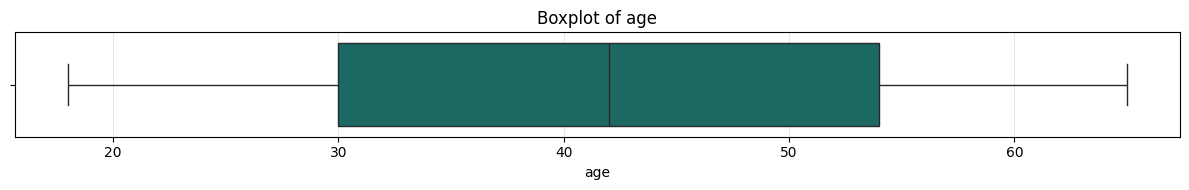

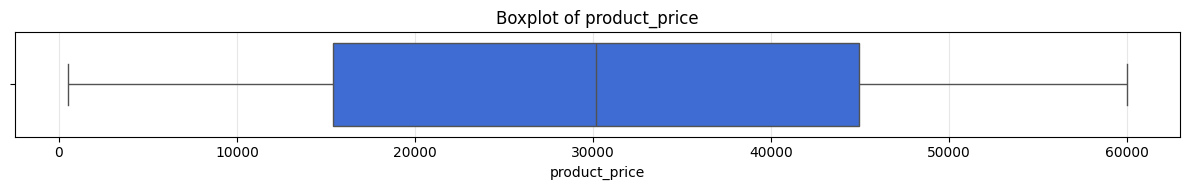

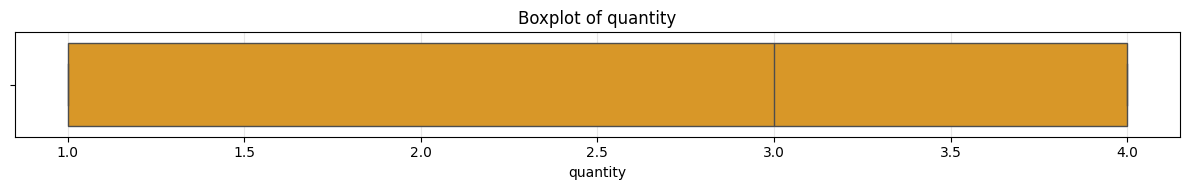

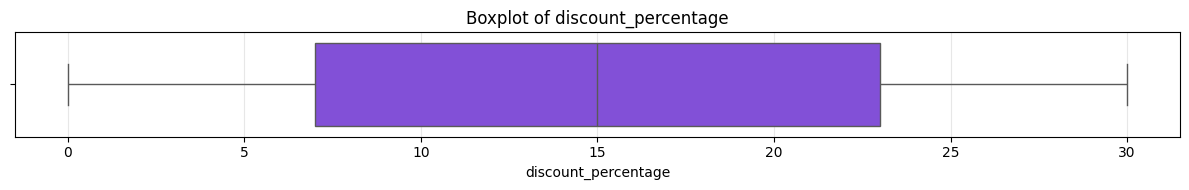

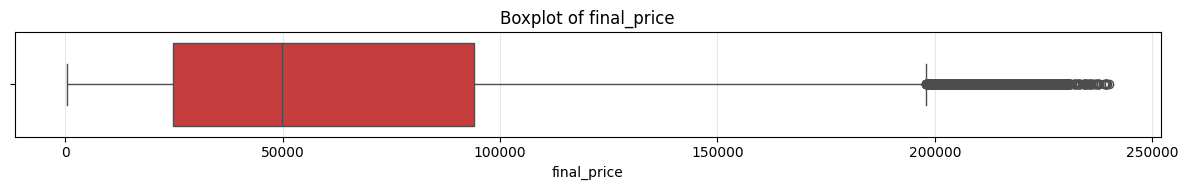

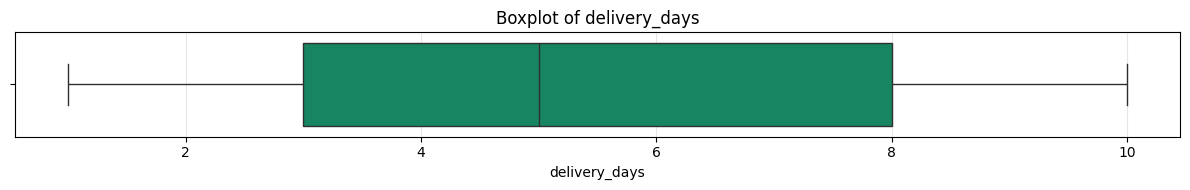

In [195]:
colors = ['#0F766E','#2563EB','#F59E0B','#7C3AED','#DC2626','#059669']

for i, col in enumerate(num_cols):
    plt.figure(figsize=(12,2))
    sns.boxplot(x=df[col], color=colors[i % 6])
    plt.title(f'Boxplot of {col}')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

## Mean Median Standard Deviation

In [196]:
stats=pd.DataFrame({
                        "Mean":df[num_cols].mean(),
                        "Median":df[num_cols].median(),
                        "Std":df[num_cols].std(),
                        "Min":df[num_cols].min(),
                        "Max":df[num_cols].max(),
                        "Skewness":df[num_cols].skew(),
                        "Kurtosis":df[num_cols].kurt()
                    })

stats

,Mean,Median,Std,Min,Max,Skewness,Kurtosis
age,41.561830,42.00,13.852439,18.0,65.0,-0.004988,-1.201172
product_price,30164.526720,30148.00,17139.679807,500.0,59998.0,0.003249,-1.195106
quantity,2.501790,3.00,1.120058,1.0,4.0,-0.003067,-1.364612
discount_percentage,15.009890,15.00,8.953296,0.0,30.0,-0.003597,-1.201628
final_price,64165.723382,49752.39,49969.280150,357.0,239980.0,0.934747,0.169047
delivery_days,5.505540,5.00,2.872868,1.0,10.0,0.002270,-1.221514


Categorical Analysis

In [197]:
for col in num_cols:

    Q1=df[col].quantile(.25)
    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    outliers=df[(df[col]<lower)|(df[col]>upper)]

    print(col,len(outliers))

age 0
product_price 0
quantity 0
discount_percentage 0
final_price 1335
delivery_days 0


Z Score

In [198]:
z=np.abs(zscore(df[num_cols]))

outlier_rows=np.where(z>3)

len(outlier_rows[0])

503

Bivariate Analysis

In [199]:
corr=df[num_cols].corr()

corr

,age,product_price,quantity,discount_percentage,final_price,delivery_days
age,1.000000,-0.000814,-0.000129,-0.004035,-0.000823,-0.003954
product_price,-0.000814,1.000000,0.000950,-0.002886,0.730757,0.001554
quantity,-0.000129,0.000950,1.000000,-0.003579,0.575303,0.004017
discount_percentage,-0.004035,-0.002886,-0.003579,1.000000,-0.137332,-0.000453
final_price,-0.000823,0.730757,0.575303,-0.137332,1.000000,0.003789
delivery_days,-0.003954,0.001554,0.004017,-0.000453,0.003789,1.000000


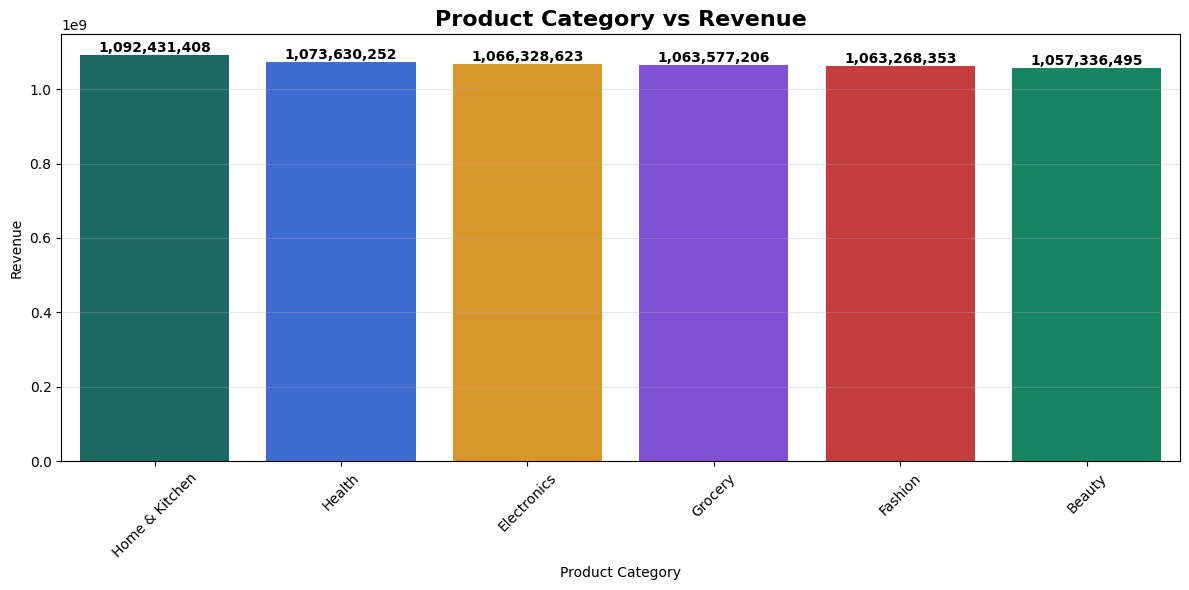

In [200]:
# Product Category vs Revenue

revenue = df.groupby('product_category')['final_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=revenue.index, y=revenue.values,
                 palette=['#0F766E','#2563EB','#F59E0B','#7C3AED','#DC2626','#059669'])

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Product Category vs Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Product Category vs Revenue

## Objective

Analyze the total revenue generated by each product category to identify high-performing and low-performing categories, supporting product performance evaluation and business decision-making.

### Analysis Workflow
- Aggregate total revenue for each product category.
- Rank categories based on revenue.
- Visualize revenue distribution using a bar chart.
- Display revenue values above each bar for easy comparison.

### Business Insights
- Compare revenue contribution across product categories.
- Identify the highest- and lowest-revenue categories.
- Evaluate product category performance.
- Support inventory planning, marketing strategies, and sales optimization.

Analyze the date range covered by the dataset
To analyze the date range covered by the dataset, we first need to identify the column that contains date information. 
Assuming there is a column named 'date' or similar, we can convert it to a datetime format and then find the minimum and maximum dates to determine the range.

In [201]:
# Convert the order_date column to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

In [202]:
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)

In [203]:
# Convert order_date to datetime (if needed)
df['order_date'] = pd.to_datetime(df['order_date'])

# Calculate date range
dataset_start = df['order_date'].min()
dataset_end = df['order_date'].max()
analysis_period = (dataset_end - dataset_start).days

# Generate summary
expected_days = 1096
missing_days = expected_days - analysis_period

print("\nAnalysis Summary")
print("-" * 60)
print(f"• Dataset period     : {dataset_start:%d-%b-%Y} to {dataset_end:%d-%b-%Y}")
print(f"• Total duration     : {analysis_period:,} days ({analysis_period/365:.2f} years)")
print(f"• Expected duration  : {expected_days:,} days")
print(f"• Missing days       : {missing_days}")

if missing_days > 0:
    print("• Data completeness should be validated before trend or time-series analysis.")
else:
    print("• No missing calendar days detected within the analysis period.")


Analysis Summary
------------------------------------------------------------
• Dataset period     : 01-Jan-2023 to 30-Dec-2025
• Total duration     : 1,094 days (3.00 years)
• Expected duration  : 1,096 days
• Missing days       : 2
• Data completeness should be validated before trend or time-series analysis.


Yearly Order Distribution

**Objective:** Analyze the annual distribution of customer orders to identify yearly order trends and compare order volumes across different years.

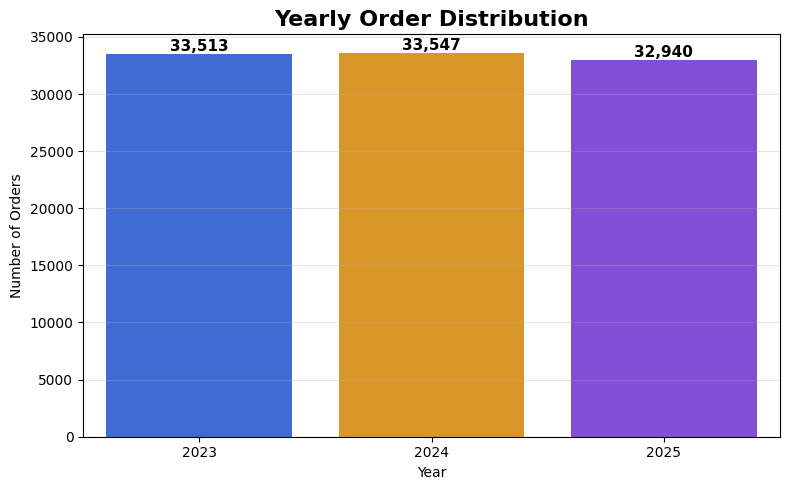

In [204]:
year_counts=df['order_date'].dt.year.value_counts().sort_index()

plt.figure(figsize=(8,5)); ax=sns.barplot(x=year_counts.index,y=year_counts.values,palette=['#2563EB','#F59E0B','#7C3AED'])
for p in ax.patches: ax.annotate(f'{int(p.get_height()):,}',(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='bottom',fontsize=11,fontweight='bold')
plt.title("Yearly Order Distribution",fontsize=16,fontweight='bold'); plt.xlabel("Year"); plt.ylabel("Number of Orders"); plt.grid(axis='y',alpha=0.3); plt.tight_layout(); plt.show()

## Business Insights

- Annual order volumes remain stable across the analysis period.
- A slight decline is observed in **2025** compared to the previous two years.
- This variation is expected because the dataset does not include transactions for **31-Dec-2025**.
- No significant year-over-year fluctuations are observed, indicating consistent customer purchasing activity.

Heatmap

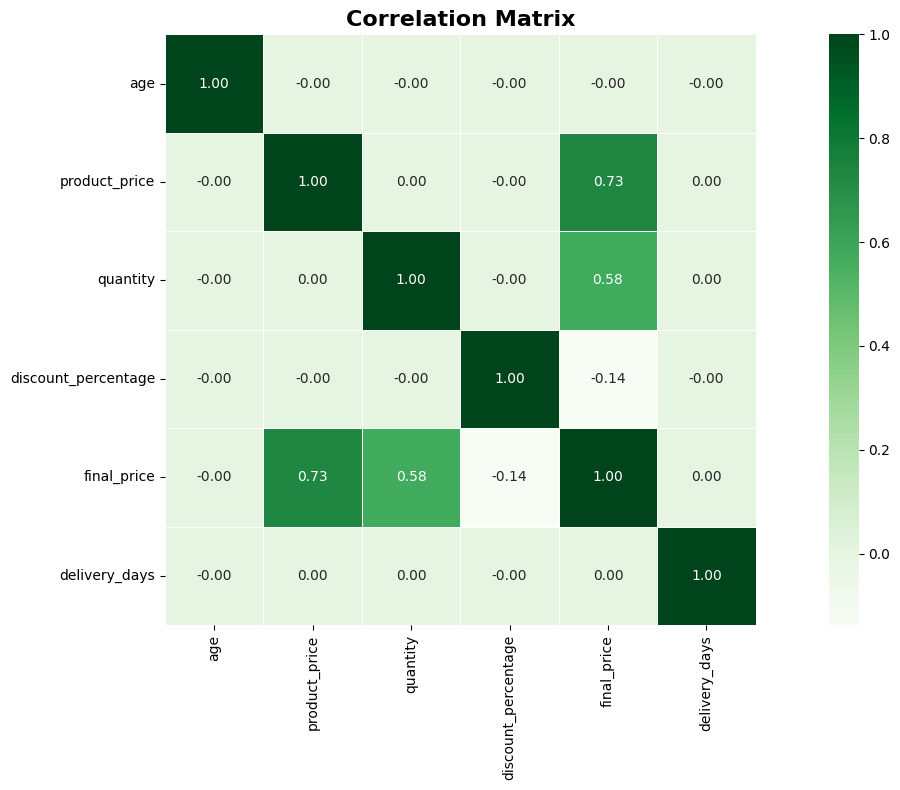

In [205]:
plt.figure(figsize=(15, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap='Greens',
    linewidths=0.5,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Scatter Plot

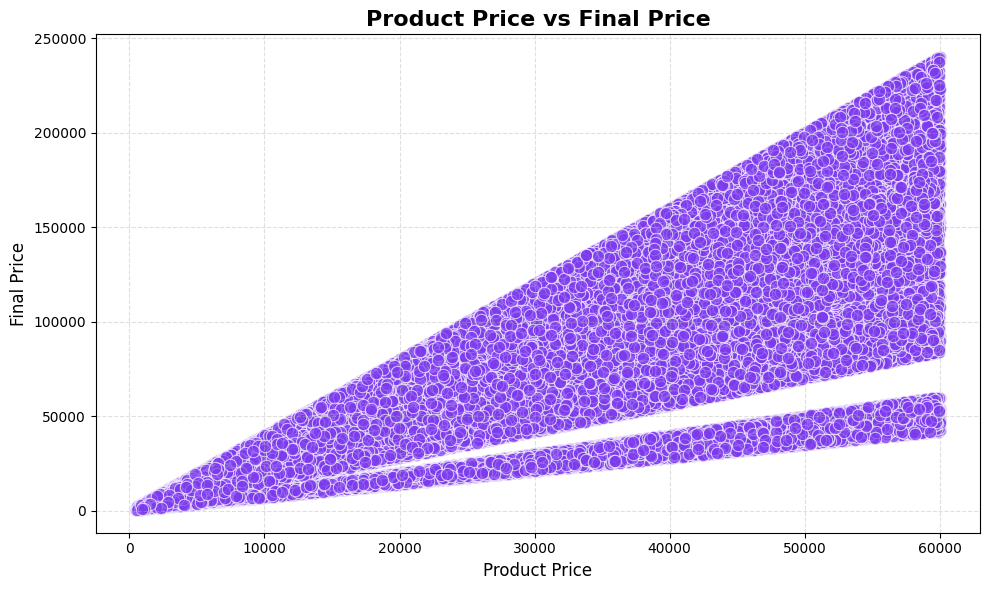

In [206]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='product_price',
    y='final_price',
    color='#7C3AED',   # Professional Purple
    s=80,
    alpha=0.7
)

plt.title("Product Price vs Final Price",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Product Price", fontsize=12)
plt.ylabel("Final Price", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Quantity vs Final Price

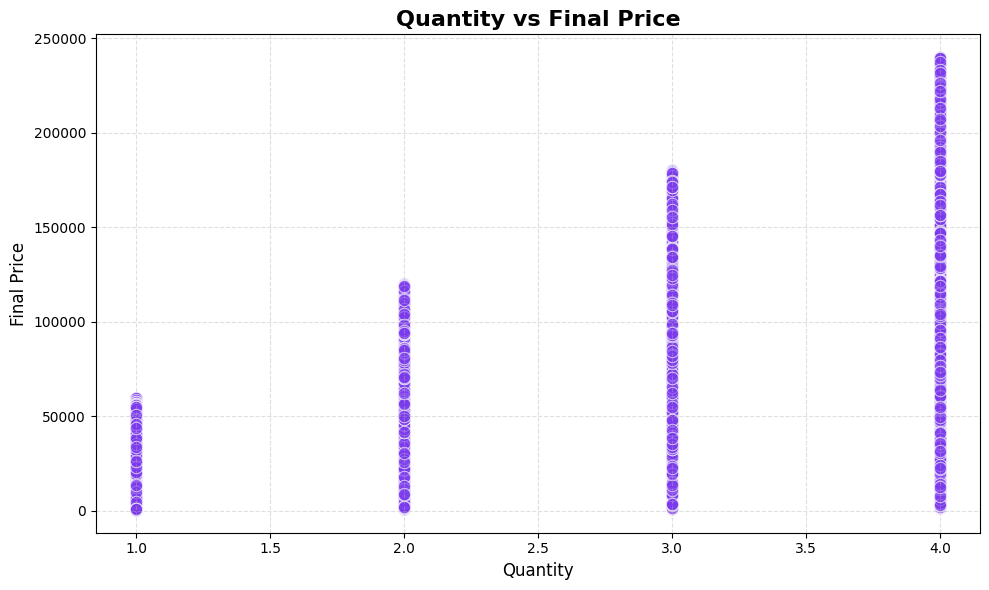

In [207]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='quantity',
    y='final_price',
    color='#7C3AED',   
    s=80,
    alpha=0.7
)

plt.title("Quantity vs Final Price",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Quantity", fontsize=12)
plt.ylabel("Final Price", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Boxplot Category vs Final Price

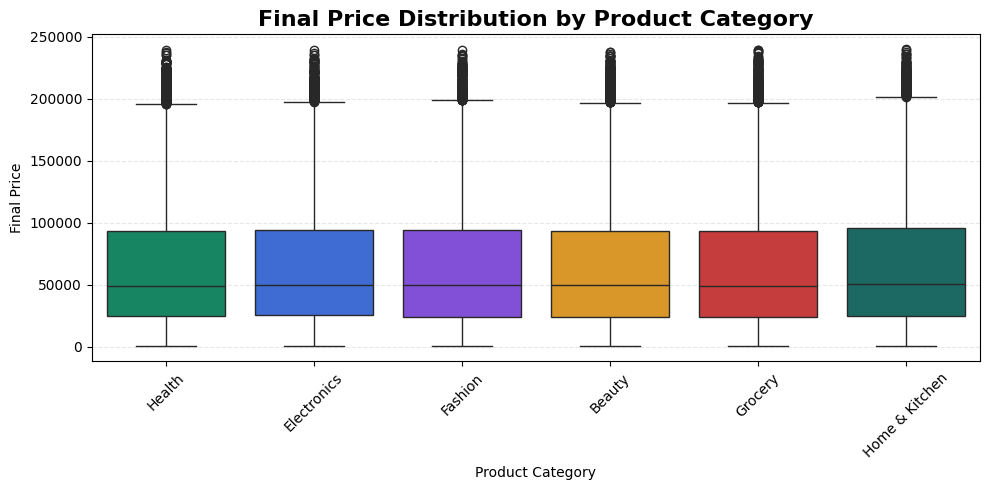

In [208]:
colors = ['#059669', '#2563EB', '#7C3AED', '#F59E0B', '#DC2626', '#0F766E']

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='product_category', y='final_price', palette=colors)

plt.title("Final Price Distribution by Product Category", fontsize=16, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Final Price")
plt.xticks(rotation=45)
plt.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

Customer Segment vs Spending

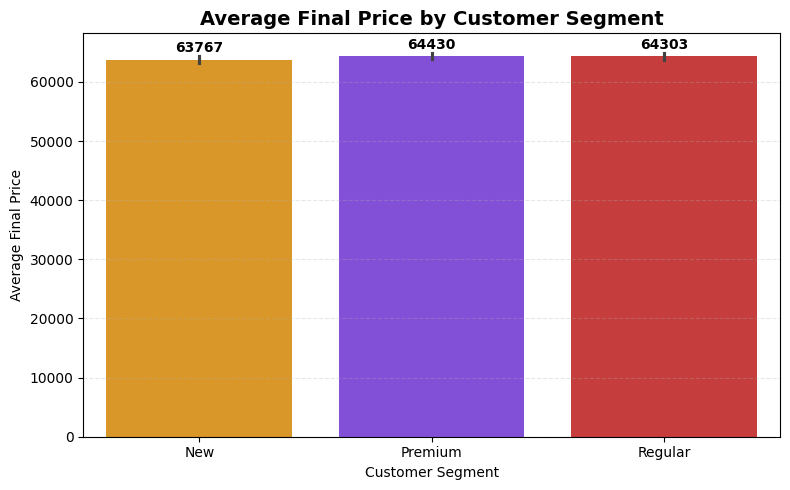

In [209]:
colors = {'New':'#F59E0B', 'Premium':'#7C3AED', 'Regular':'#DC2626'}

plt.figure(figsize=(8,5))
ax = sns.barplot(data=df,  x='customer_segment',  y='final_price',  hue='customer_segment', palette=colors, legend=False)
plt.title("Average Final Price by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Average Final Price")
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

 Shipping Type vs Delivery Days

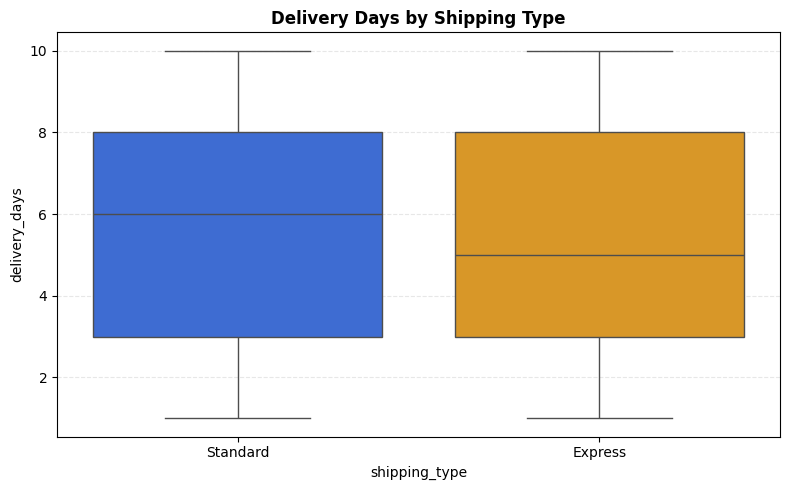

In [210]:
colors = {'Standard':'#2563EB', 'Express':'#F59E0B'}

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='shipping_type', y='delivery_days',
            hue='shipping_type', palette=colors, legend=False)

plt.title("Delivery Days by Shipping Type", fontweight='bold')
plt.grid(axis='y', ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

 Multivariate Analysis
 Pairplot

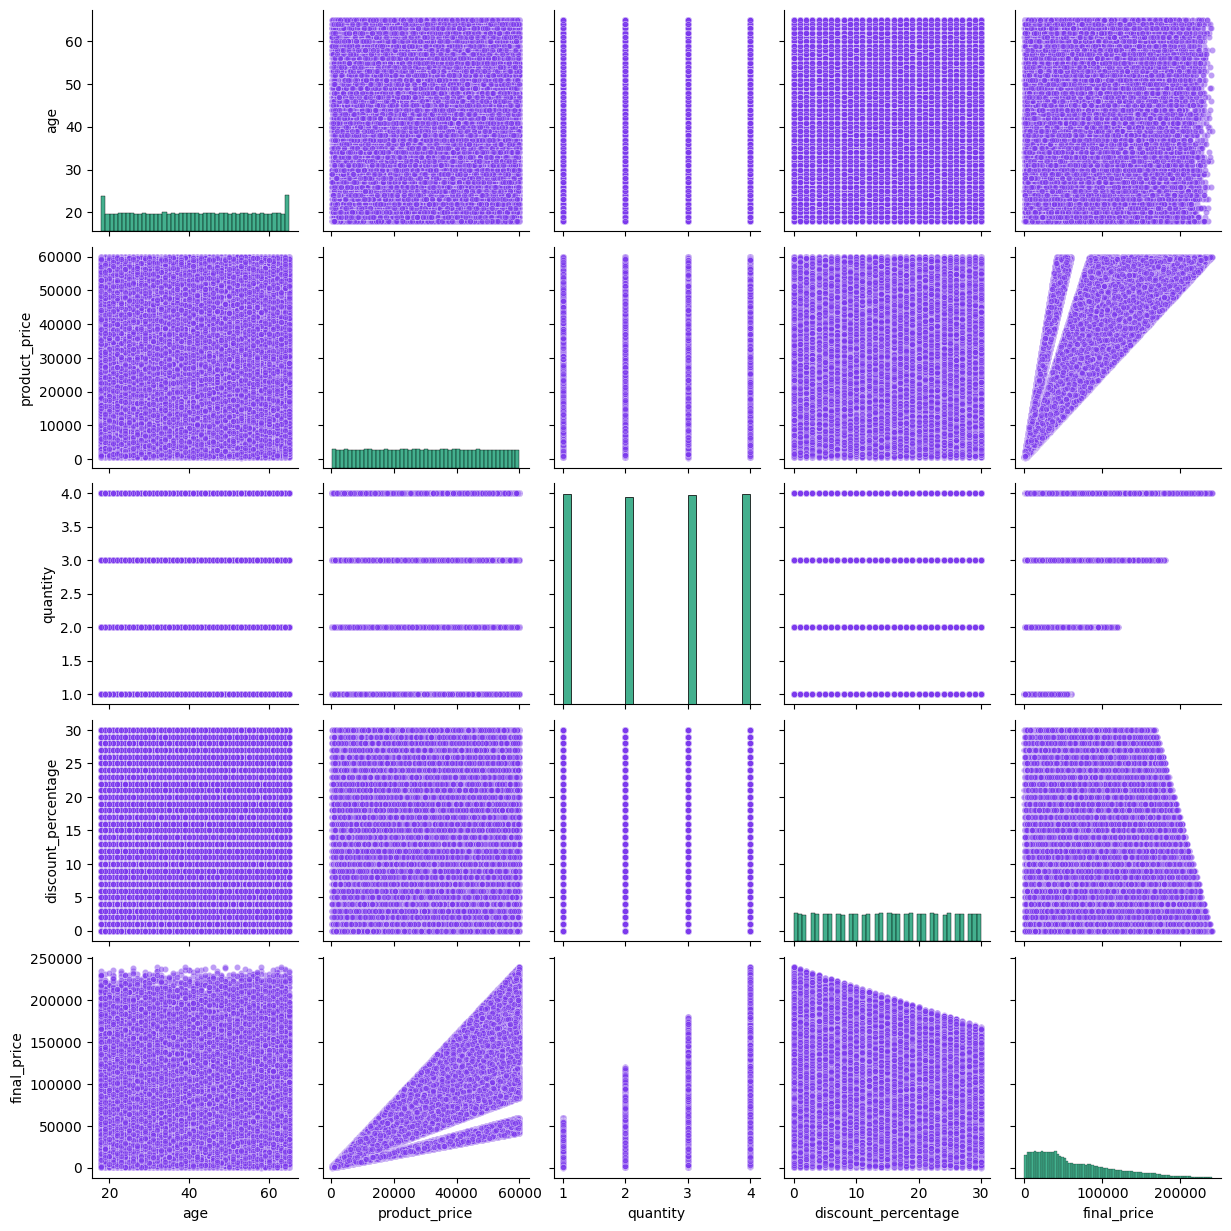

In [211]:
sns.pairplot(
    df[num_cols[:5]],
    diag_kind='hist',
    plot_kws={'color':'#7C3AED', 'alpha':0.5, 's':20},
    diag_kws={'color':'#059669'}
)
plt.show()

 Category × Discount × Final Price

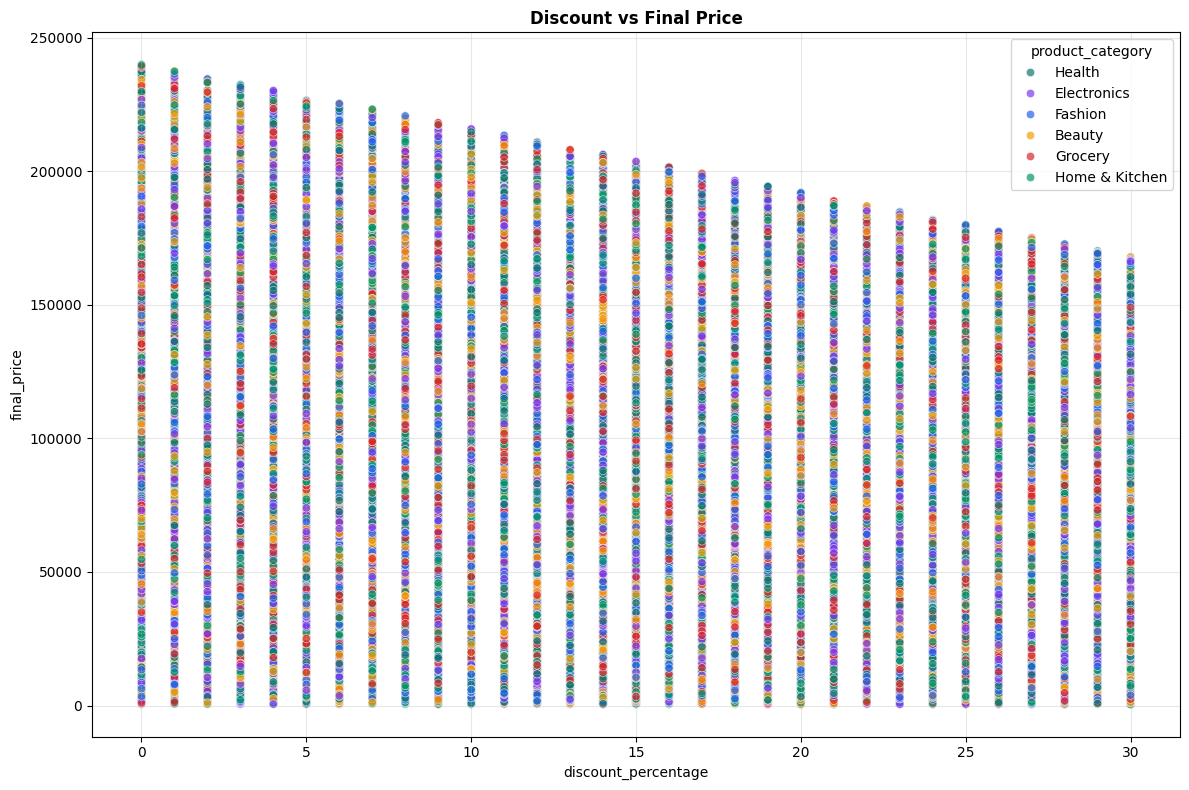

In [212]:
colors = ['#0F766E','#7C3AED','#2563EB','#F59E0B','#DC2626','#059669']

plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='discount_percentage', y='final_price',
                hue='product_category', palette=colors, alpha=0.7)

plt.title("Discount vs Final Price", fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 Age × Segment × Spending

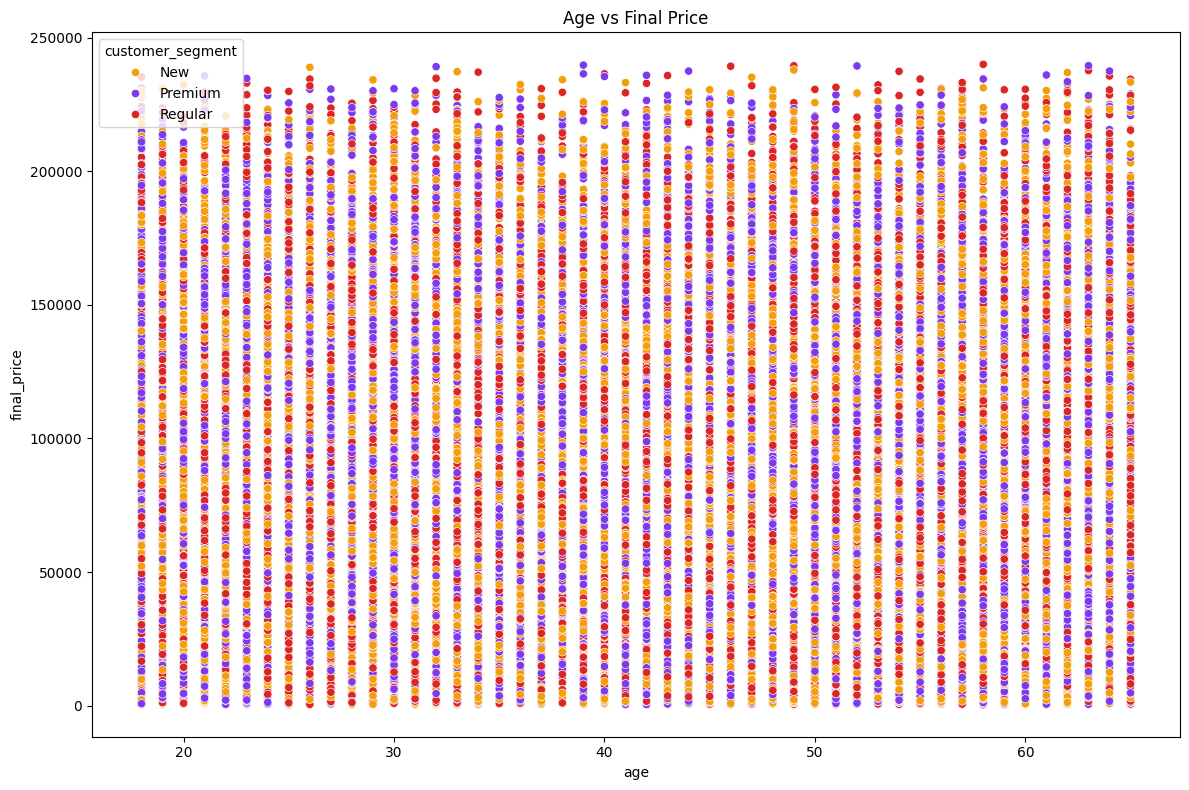

In [213]:
colors = {'New':'#F59E0B', 'Premium':'#7C3AED', 'Regular':'#DC2626'}

plt.figure(figsize=(12,8))
sns.scatterplot(data=df, x='age', y='final_price',
                hue='customer_segment', palette=colors)

plt.title("Age vs Final Price")
plt.tight_layout()
plt.show()

## Bivariate Analysis

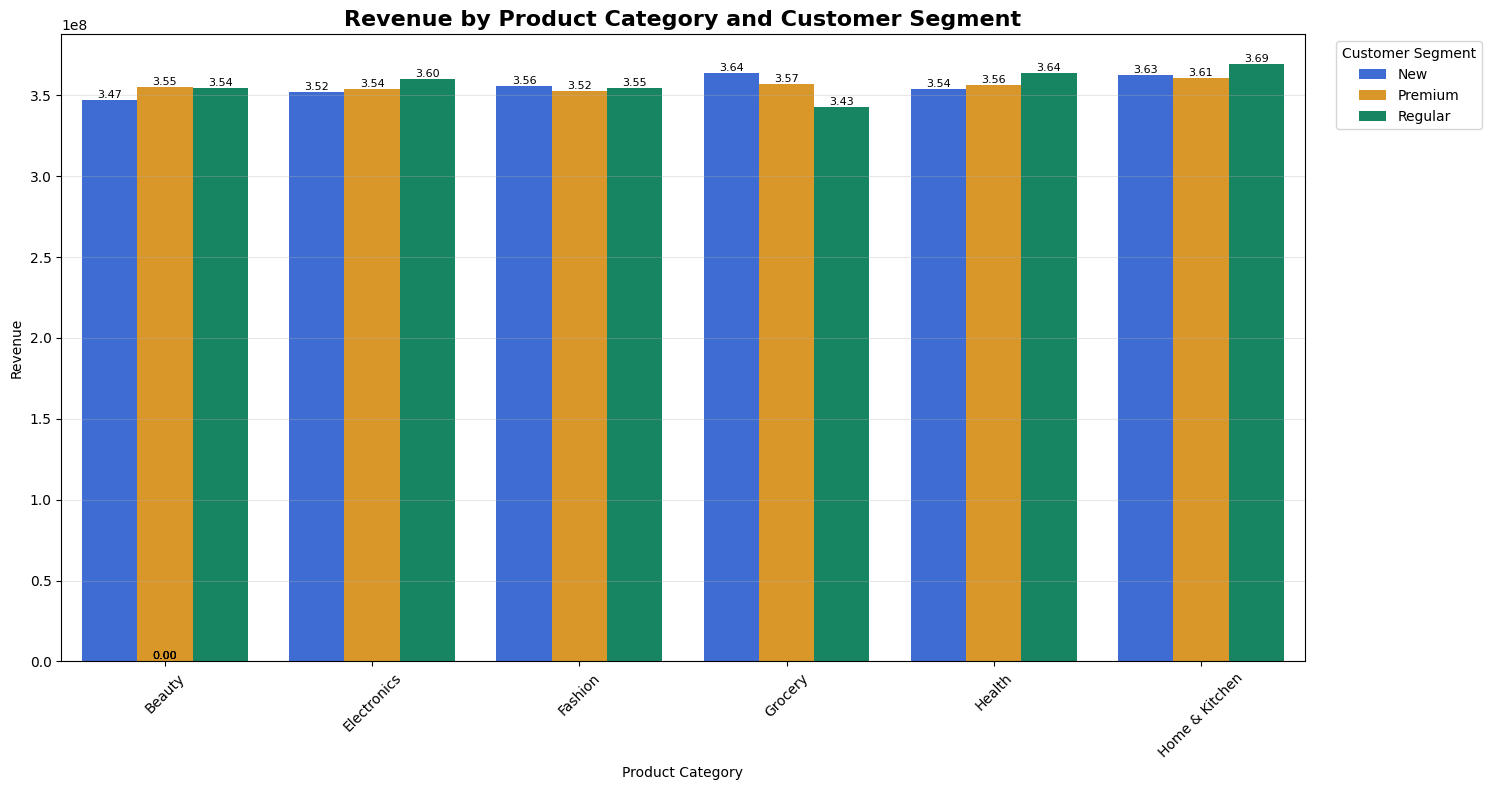

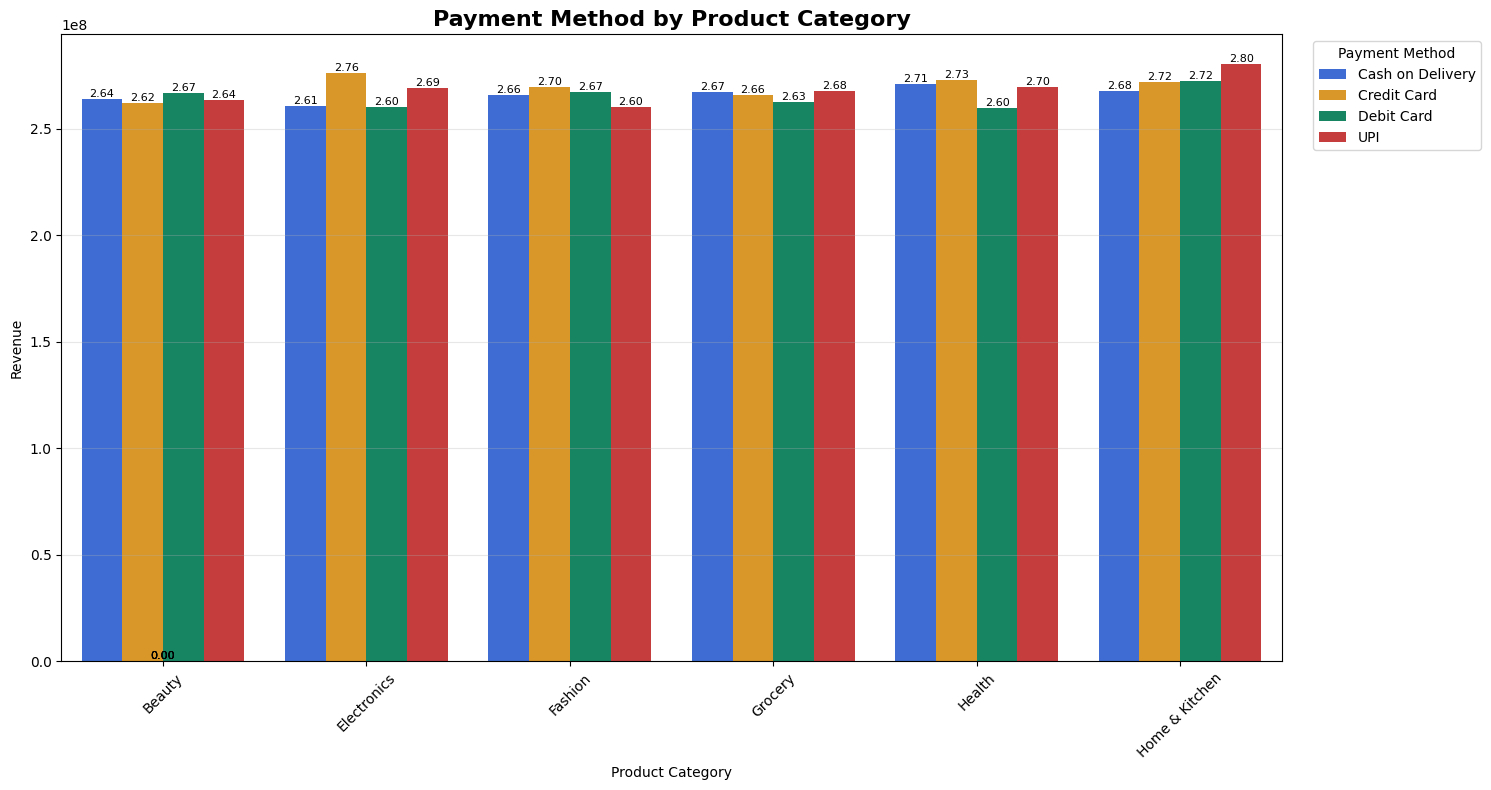

In [214]:
def plot_chart(group_col, title, colors):
    data = df.groupby(['product_category', group_col])['final_price'].sum().reset_index()

    plt.figure(figsize=(15,8))
    ax = sns.barplot(data=data, x='product_category', y='final_price',
                     hue=group_col, palette=colors)

    for p in ax.patches:
        ax.annotate(f'{p.get_height()/1e8:.2f}',
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Product Category")
    plt.ylabel("Revenue")
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(title=group_col.replace('_',' ').title(),
               loc='upper left', bbox_to_anchor=(1.02,1))
    plt.tight_layout()
    plt.show()

plot_chart('customer_segment',
           'Revenue by Product Category and Customer Segment',
           ['#2563EB','#F59E0B','#059669'])

plot_chart('payment_method',
           'Payment Method by Product Category',
           ['#2563EB','#F59E0B','#059669','#DC2626'])

## Revenue Analysis by Product Category

### Objective
Evaluate revenue across product categories by customer segment and payment method to understand customer purchasing behavior and payment preferences.

---

## Analysis 1: Revenue by Customer Segment

### Description
This analysis compares total revenue generated by each customer segment across different product categories.

### Business Purpose
- Compare revenue contribution of New, Premium, and Regular customers.
- Identify high-value customer segments.
- Understand customer purchasing patterns.
- Support customer segmentation strategies.

---

## Analysis 2: Revenue by Payment Method

### Description
This analysis compares total revenue generated through different payment methods for each product category.

### Business Purpose
- Analyze customer payment preferences.
- Compare revenue generated by each payment method.
- Identify the most preferred payment options.
- Support payment and checkout optimization.

## Average Final Price by Age Group and Customer Segment


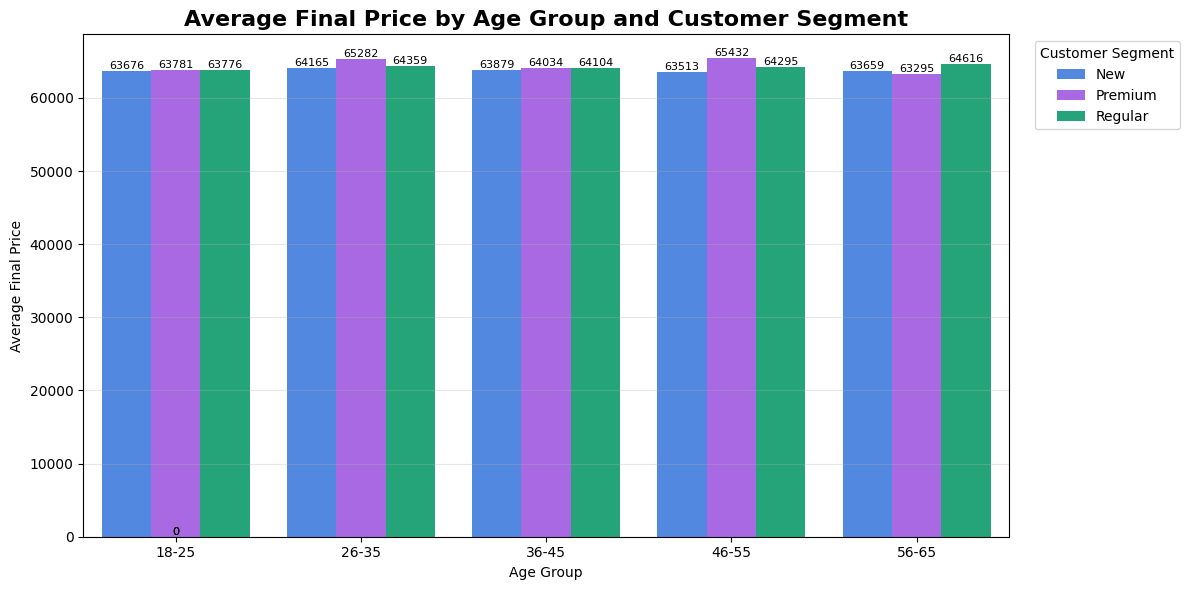

In [215]:
# Create Age Group categories
df['Age Group'] = pd.cut(
    df['age'],
    bins=[18,25,35,45,55,65],
    labels=['18-25','26-35','36-45','46-55','56-65']
)

# Calculate average final price
age_group = df.groupby(['Age Group','customer_segment'])['final_price'].mean().reset_index()

# Plot bar chart
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=age_group,
    x='Age Group',
    y='final_price',
    hue='customer_segment',
    palette=['#3B82F6','#A855F7','#10B981']
)

# Display values on bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)

# Customize the chart
plt.title("Average Final Price by Age Group and Customer Segment", fontsize=16, fontweight='bold')
plt.xlabel("Age Group")
plt.ylabel("Average Final Price")
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Customer Segment', loc='upper left', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

## Objective

Analyze the average final price across different age groups and customer segments to understand purchasing behavior and spending patterns.

### Analysis Workflow
- Create age groups from customer age.
- Calculate the average final price for each age group.
- Compare average spending across customer segments.
- Visualize the results using a grouped bar chart.

### Business Insights
- Compare spending behavior across different age groups.
- Identify high-value customer segments.
- Understand purchasing trends by age.
- Support customer segmentation and targeted marketing strategies.

# Revenue by State and Product Category

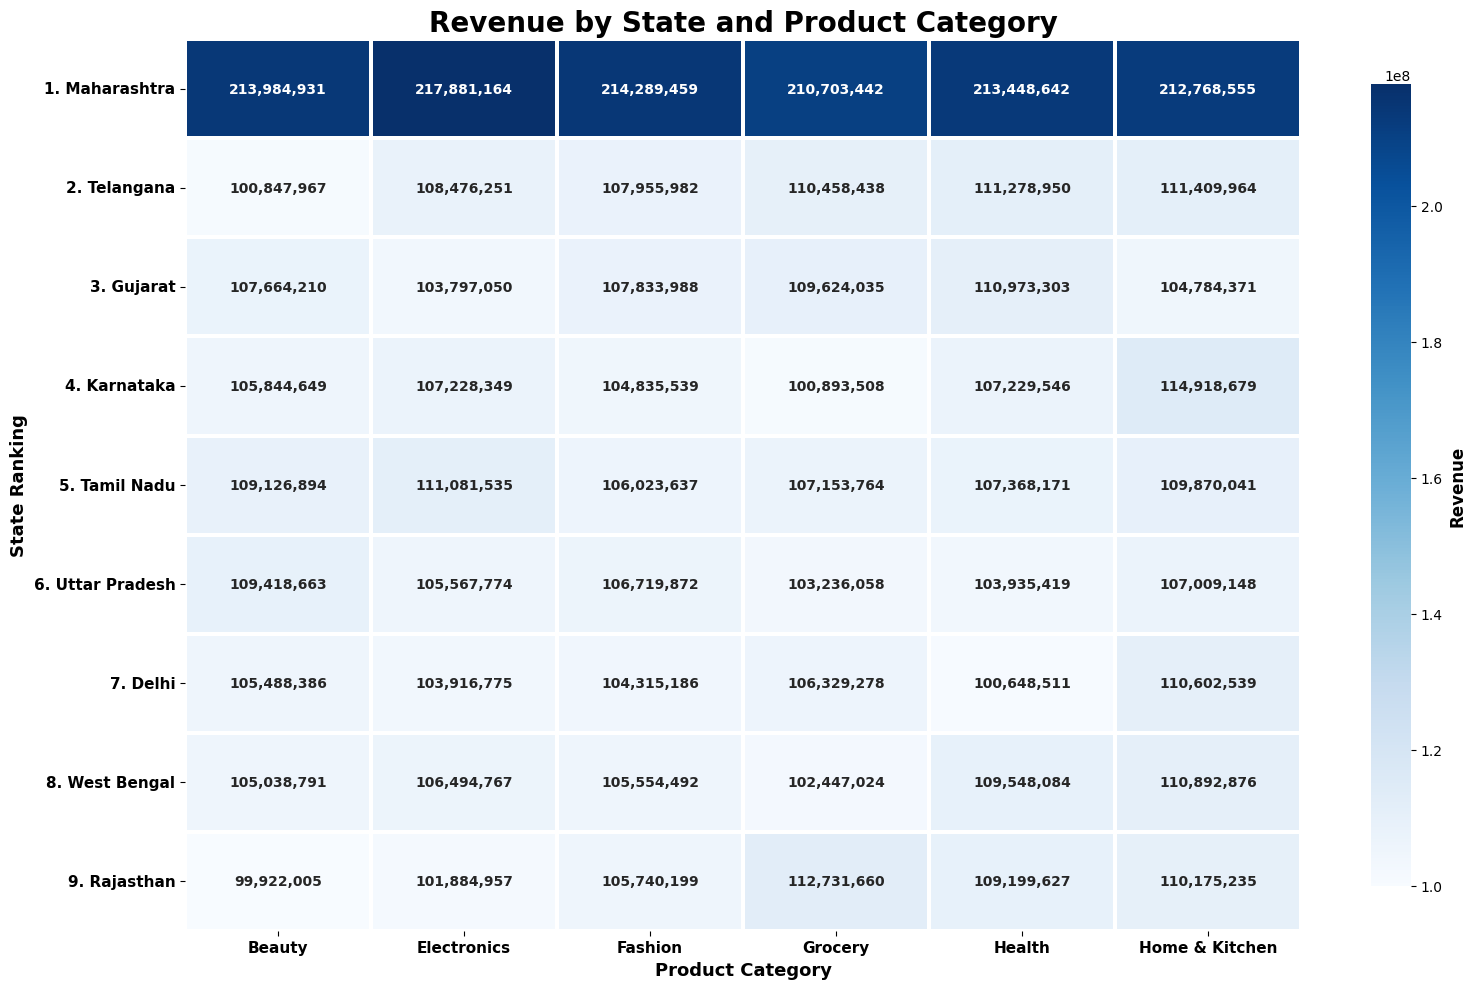

In [216]:
# Revenue by State and Product Category

state_order=['Maharashtra','Telangana','Gujarat','Karnataka','Tamil Nadu',
             'Uttar Pradesh','Delhi','West Bengal','Rajasthan']

rank_labels=[f'{i+1}. {s}' for i,s in enumerate(state_order)]

pivot=df.pivot_table(values='final_price',
                     index='state',
                     columns='product_category',
                     aggfunc='sum').reindex(state_order)

plt.figure(figsize=(16,10))

ax=sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='Blues',
    linewidths=1.5,
    linecolor='white',
    cbar_kws={'label':'Revenue','shrink':0.9},
    annot_kws={'fontsize':10,'fontweight':'bold'}
)

plt.title('Revenue by State and Product Category',fontsize=20,fontweight='bold')
plt.xlabel('Product Category',fontsize=13,fontweight='bold')
plt.ylabel('State Ranking',fontsize=13,fontweight='bold')

plt.xticks(rotation=0,fontsize=11,fontweight='bold')
plt.yticks([i+0.5 for i in range(len(rank_labels))],rank_labels,
           rotation=0,fontsize=11,fontweight='bold')

ax.collections[0].colorbar.set_label('Revenue',fontsize=12,fontweight='bold')

plt.tight_layout()
plt.show()


## Objective

Analyze the revenue generated across different states and product categories to identify high-performing regions, compare product demand, and support data-driven business decisions.

### Analysis Workflow

- Aggregate total revenue by **State** and **Product Category**.
- Rank states based on overall revenue performance.
- Visualize revenue distribution using a heatmap.
- Compare product category performance across different states.
- Highlight regional revenue patterns and business opportunities.

### Business Value

- Identify top-performing states by revenue.
- Compare product category performance across regions.
- Detect high- and low-revenue markets.
- Support regional sales strategy and inventory planning.
- Assist marketing, pricing, and business expansion decisions.